# Diabetes Health Indicators
# Lab 1: Exploratory Data Analysis

## BRFSS 2015 Diabetes Health Indicators Dataset

**Project Team:** Harvey, Sydney, Wolfgang, Nashita
**Course:** Intro to AI
**Date:** September 2026

# 1. Introduction

## 1.1 Purpose of the Dataset

The purpose of this dataset is to better understand the relationship
between lifestyle, health conditions, demographic characteristics, and diabetes
in the United States.

The data comes from the Behavioral Risk Factor Surveillance System (BRFSS) and
contains information about health behaviors, health conditions, access to
healthcare, and demographic characteristics reported by individuals.

The dataset is useful because diabetes is an important public health concern, and
understanding which characteristics are associated with it helps identify
populations that may be at higher risk.

The primary question for this analysis is:

> **Which health, lifestyle, and demographic characteristics are most strongly
> associated with diagnosed diabetes?**

A secondary goal is to determine whether these characteristics can be used to
build a machine-learning model that usefully ranks individuals by diabetes risk
and, as Section 15.2 explores, whether that ranking can point to people whose
diabetes is real but undiagnosed.

## 1.2 Defining and Measuring the Outcomes

The raw outcome variable in the source file is `Diabetes_012`:

| Value | Meaning |
|---:|---|
| 0 | No diabetes |
| 1 | Prediabetes |
| 2 | Diabetes |

The group works with a binary collapse of this
variable, `Diabetes_binary = 1` if `Diabetes_012 == 2` (diagnosed diabetes) and `0`
otherwise (no diabetes or prediabetes). Section 6 below shows why: prediabetes
is a small class (~1.8% of rows) with no profile of its own. Section 10's
group-wise comparison shows it sits consistently *between* the other two classes on
every measured attribute, which is exactly what makes it hard to separate from
either as a third class.

Useful knowledge is considered to have been discovered if the analysis identifies
meaningful relationships between diagnosed diabetes and variables such as:

- High blood pressure
- High cholesterol
- BMI
- Age
- General health
- Physical activity
- Smoking
- Heart disease
- Stroke
- Physical / mental health
- Income
- Education

## 1.3 Measuring the Effectiveness of a Prediction Algorithm

Since the team settled on a classification task (diagnosed
diabetes vs. not) rather than a numeric forecast, the metrics that actually apply
from that list are the classification ones (namely Accuracy, Precision, Recall,
F1-score, and ROC-AUC) extended below with PR-AUC and balanced accuracy, which
matter more here than plain accuracy once the class imbalance is accounted for.
The error-based metrics (MAE, RMSE, MAPE, MSE) are the
right family for a *numeric* prediction and they resurface in Section 15.2's
Brier score, which is exactly the mean squared error of a predicted probability
against the 0/1 outcome. So the "MSE of forecast errors" idea in the original
answer is not discarded, it is the metric used once the model's output is treated
as a probability rather than a hard yes/no.

The target is highly imbalanced: under the binary framing, diagnosed diabetes is
about 13.9% of respondents, so about 86.1% are coded 0.

Accuracy is not usable as a primary metric here. A model that predicts "no
diabetes" for every single person achieves about 86% accuracy while being
completely useless, because it identifies zero diabetics. Any reported accuracy
must be compared against that floor, not against zero.

The metrics we would actually use, and why:

| Metric | What it measures | Why it matters here |
|---|---|---|
| **Recall (sensitivity)** | Of people with diabetes, what share did we flag? | A missed diabetic goes untreated. This is the costliest error. |
| **Precision** | Of the people we flagged, what share truly have diabetes? | Governs how much screening capacity is wasted on false alarms. |
| **F1-score** | Harmonic mean of precision and recall | Single number when both errors matter, but it hides which one dominates. |
| **ROC-AUC** | Ranking quality across all thresholds | Threshold-independent, but optimistic under heavy imbalance. |
| **PR-AUC** | Precision-recall tradeoff across thresholds | More informative than ROC-AUC when positives are rare. Preferred here. |
| **Balanced accuracy** | Mean of per-class recall | Reports whether the minority class is handled at all. |
| **Brier score** | Mean squared error of the predicted probability | The MSE-style metric from the original answer, applied to a probability instead of a hard label (Section 15.2). |

### Why binary, not three-class 

Prediabetes is only about 1.8 percent of the data, 
which is a small sample
for reliable three-class prediction, and a class with no profile of
its own, sitting between the other two on nearly every attribute. A three-class
model would be expected to report near-zero recall for it. The binary formulation
of diagnosed diabetes against the rest is the more defensible task, and it is the
one this notebook uses throughout, including in both models in Section 15.

# 2. Setup and Data Loading

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "600"

# Consistent colors used throughout the notebook.
# C_NO / C_DIA follow the binary framing; C_PRE is kept only for the
# occasional three-class chart in Section 6 that shows where prediabetes sits.
C_NO, C_PRE, C_DIA = "#7f9bb0", "#e0a458", "#8c2f5f"
PALETTE_012 = [C_NO, C_PRE, C_DIA]

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
raw = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

print(f"rows    : {raw.shape[0]:,}")
print(f"columns : {raw.shape[1]}")

rows    : 253,680
columns : 22


We build the binary target here, immediately after
loading, so every section from this point on works against the same column. The
original three-class column is kept (renamed `Diabetes_012`) for where showing where prediabetes sits is the point.

In [5]:
# Diabetes_012: 0 = no diabetes, 1 = prediabetes, 2 = diabetes (self-reported diagnosis)
# Decision #1: collapse to Diabetes_binary = 1 iff diagnosed diabetes (class 2).
# Prediabetes (class 1) joins the negative class rather than being dropped or
# folded into the positive class, because Section 10 shows it has no profile of
# its own and Section 1.3 explains why 3-class modeling is not the better task.
raw["Diabetes_binary"] = (raw["Diabetes_012"] == 2).astype(int)

TARGET   = "Diabetes_binary"
FEATURES = [c for c in raw.columns if c not in ("Diabetes_012", "Diabetes_binary")]

print(f"target     : {TARGET}, prevalence {100*raw[TARGET].mean():.2f}%")
print(f"features   : {len(FEATURES)}")
print(f"3-class counts for reference:")
print(raw.Diabetes_012.value_counts().sort_index().rename({0:"no diabetes",1:"prediabetes",2:"diabetes"}))

target     : Diabetes_binary, prevalence 13.93%
features   : 21
3-class counts for reference:
Diabetes_012
no diabetes    213703
prediabetes      4631
diabetes        35346
Name: count, dtype: int64


# 3. Data Understanding

In [6]:
raw.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.000,1.000,1.000,1.000,40.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,5.000,18.000,15.000,1.000,0.000,9.000,4.000,3.000,0
1,0.000,0.000,0.000,0.000,25.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,3.000,0.000,0.000,0.000,0.000,7.000,6.000,1.000,0
2,0.000,1.000,1.000,1.000,28.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,5.000,30.000,30.000,1.000,0.000,9.000,4.000,8.000,0
3,0.000,1.000,0.000,1.000,27.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,0.000,11.000,3.000,6.000,0
4,0.000,1.000,1.000,1.000,24.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,3.000,0.000,0.000,0.000,11.000,5.000,4.000,0
5,0.000,1.000,1.000,1.000,25.000,1.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,2.000,0.000,2.000,0.000,1.000,10.000,6.000,8.000,0
6,0.000,1.000,0.000,1.000,30.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,3.000,0.000,14.000,0.000,0.000,9.000,6.000,7.000,0
7,0.000,1.000,1.000,1.000,25.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,3.000,0.000,0.000,1.000,0.000,11.000,4.000,4.000,0
8,2.000,1.000,1.000,1.000,30.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000,1.000,0.000,5.000,30.000,30.000,1.000,0.000,9.000,5.000,1.000,1
9,0.000,0.000,0.000,1.000,24.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,2.000,0.000,0.000,0.000,1.000,8.000,4.000,3.000,0


In [7]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

## 3.1 Attribute Descriptions

Every column in this file is stored as `float64`, but that storage type is
misleading, because only one variable, BMI, is a true continuous measurement. The
rest are binary flags or integer codes standing in for categories, and several
of those codes are ordered, which changes how they should be treated.

The `Scale` column below uses the standard measurement-scale terms, because the
scale determines which statistics are meaningful. Computing a mean of a nominal
code is meaningless; computing one for an ordinal code is only interpretable with
care.

| # | Attribute | Type | Scale | Values | Description |
|---:|---|---|---|---|---|
| 1 | `Diabetes_binary` | Categorical | Nominal | 0, 1 | **Target.** 1 = diagnosed diabetes (`Diabetes_012 == 2`); 0 = no diabetes or prediabetes. See Decision #1. |
| 2 | `HighBP` | Binary | Nominal | 0, 1 | Ever told by a health professional they have high blood pressure. |
| 3 | `HighChol` | Binary | Nominal | 0, 1 | Ever told they have high cholesterol. |
| 4 | `CholCheck` | Binary | Nominal | 0, 1 | Cholesterol checked within the past 5 years. |
| 5 | `BMI` | Numeric | Ratio | 12-98 | Body Mass Index, derived from self-reported height and weight. See Section 4.3 for capping. |
| 6 | `Smoker` | Binary | Nominal | 0, 1 | Smoked >= 100 cigarettes in lifetime. **Not** current smoking status. |
| 7 | `Stroke` | Binary | Nominal | 0, 1 | Ever told they had a stroke. |
| 8 | `HeartDiseaseorAttack` | Binary | Nominal | 0, 1 | Ever reported CHD or myocardial infarction. |
| 9 | `PhysActivity` | Binary | Nominal | 0, 1 | Any physical activity in past 30 days outside of work. |
| 10 | `Fruits` | Binary | Nominal | 0, 1 | Consumes fruit >=1 time per day. |
| 11 | `Veggies` | Binary | Nominal | 0, 1 | Consumes vegetables >=1 time per day. |
| 12 | `HvyAlcoholConsump` | Binary | Nominal | 0, 1 | Heavy drinker (M > 14, F > 7 drinks/week). |
| 13 | `AnyHealthcare` | Binary | Nominal | 0, 1 | Has any health care coverage. |
| 14 | `NoDocbcCost` | Binary | Nominal | 0, 1 | Needed a doctor in past 12m but could not afford one. |
| 15 | `GenHlth` | Ordinal | Ordinal | 1-5 | Self-rated general health: 1 = Excellent ... 5 = Poor. |
| 16 | `MentHlth` | Count | Interval-ish | 0-30 | Days in past 30 mental health was not good. Zero-inflated — see Section 4.4. |
| 17 | `PhysHlth` | Count | Interval-ish | 0-30 | Days in past 30 physical health was not good. Zero-inflated — see Section 4.4. |
| 18 | `DiffWalk` | Binary | Nominal | 0, 1 | Serious difficulty walking or climbing stairs. |
| 19 | `Sex` | Binary | Nominal | 0, 1 | 0 = female, 1 = male. |
| 20 | `Age` | Ordinal | Ordinal | 1-13 | 13 five-year age bands, 18-24 through 80+. |
| 21 | `Education` | Ordinal | Ordinal | 1-6 | Highest grade or year of school completed. |
| 22 | `Income` | Ordinal | Ordinal | 1-8 | Household income bracket. |

`CholCheck`, `AnyHealthcare`, and `NoDocbcCost` deserve a flag up front because portions of the EDA treat them as healthcare-*access* variables rather than health variables,
because they measure contact with the health system, not the underlying condition.

In [8]:
# Confirm the coded ranges match the documentation above (codebook audit)
EXPECTED = {"Diabetes_binary":(0,1), "Diabetes_012":(0,2), "HighBP":(0,1), "HighChol":(0,1),
            "CholCheck":(0,1), "BMI":(12,98), "Smoker":(0,1), "Stroke":(0,1),
            "HeartDiseaseorAttack":(0,1), "PhysActivity":(0,1), "Fruits":(0,1),
            "Veggies":(0,1), "HvyAlcoholConsump":(0,1), "AnyHealthcare":(0,1),
            "NoDocbcCost":(0,1), "GenHlth":(1,5), "MentHlth":(0,30), "PhysHlth":(0,30),
            "DiffWalk":(0,1), "Sex":(0,1), "Age":(1,13), "Education":(1,6), "Income":(1,8)}

audit = pd.DataFrame({
    "min":            raw.min(),
    "max":            raw.max(),
    "n_unique":       raw.nunique(),
    "non_integer":    [(raw[c] % 1 != 0).sum() for c in raw.columns],
})
audit["codebook"] = [f"{EXPECTED[c][0]}-{EXPECTED[c][1]}" for c in raw.columns]
audit["in_range"] = [bool(raw[c].between(*EXPECTED[c]).all()) for c in raw.columns]

display(audit)
print(f"columns outside codebook range : {(~audit.in_range).sum()}")
print(f"non-integer values anywhere    : {audit.non_integer.sum()}")

,min,max,n_unique,non_integer,codebook,in_range
Diabetes_012,0.000,2.000,3,0,0-2,True
HighBP,0.000,1.000,2,0,0-1,True
HighChol,0.000,1.000,2,0,0-1,True
CholCheck,0.000,1.000,2,0,0-1,True
BMI,12.000,98.000,84,0,12-98,True
Smoker,0.000,1.000,2,0,0-1,True
Stroke,0.000,1.000,2,0,0-1,True
HeartDiseaseorAttack,0.000,1.000,2,0,0-1,True
PhysActivity,0.000,1.000,2,0,0-1,True
Fruits,0.000,1.000,2,0,0-1,True


columns outside codebook range : 0
non-integer values anywhere    : 0


The observed ranges match the documented codings exactly. There are no
out-of-range values, no negative entries, and no sentinel codes such as 7, 9, or
99 (the "don't know / refused" markers used in the raw BRFSS). This confirms the
file is a pre-cleaned extract rather than the raw survey a point Section 5
returns to when comparing this sample against the general population, since
roughly 43% of the original BRFSS respondents are absent by construction (incomplete
records were filtered out before this CSV was written).

## 3.2 Simple, Appropriate Statistics for Key Attributes

Range, mode, mean, median, and variance mean different things depending on a
variable's measurement scale (Section 3.1), so this section reports the
statistic that's actually appropriate for each key attribute rather than running
`.describe()` on everything uniformly.

- BMI is the one true continuous/ratio variable: mean, median, and variance
  all apply.
- GenHlth, Age, Education, Income are ordinal: median and mode are
  meaningful; a mean is only cautiously interpretable (it assumes equal spacing
  between categories, which Section 7.3's Age curve shows isn't quite true).
- MentHlth, PhysHlth are counts with a zero-inflated, bimodal shape (Section
  4.4 revisits this): the mean is reported here for completeness but is flagged
  as potentially misleading on its own.
- The binary indicators (HighBP, HighChol, Smoker, etc.) are nominal: only a
  proportion/count is meaningful, not a mean, median, or variance in the usual
  sense (their "mean" is just their proportion of 1s, shown here for reference).

In [9]:
key_numeric = ["BMI", "GenHlth", "Age", "Education", "Income", "MentHlth", "PhysHlth"]

stats_table = pd.DataFrame({
    "count":    raw[key_numeric].count(),
    "min":      raw[key_numeric].min(),
    "max":      raw[key_numeric].max(),
    "mode":     raw[key_numeric].mode().iloc[0],
    "median":   raw[key_numeric].median(),
    "mean":     raw[key_numeric].mean(),
    "variance": raw[key_numeric].var(),
    "std":      raw[key_numeric].std(),
})
display(stats_table.round(2))

binary_like = [c for c in FEATURES if raw[c].nunique() == 2 and c != "Sex"]
prop_table = pd.DataFrame({
    "count_1":    raw[binary_like].sum().astype(int),
    "proportion": raw[binary_like].mean(),
}).sort_values("proportion", ascending=False)
display(prop_table.round(3))

,count,min,max,mode,median,mean,variance,std
BMI,253680,12.000,98.000,27.000,27.000,28.380,43.670,6.610
GenHlth,253680,1.000,5.000,2.000,2.000,2.510,1.140,1.070
Age,253680,1.000,13.000,9.000,8.000,8.030,9.330,3.050
Education,253680,1.000,6.000,6.000,5.000,5.050,0.970,0.990
Income,253680,1.000,8.000,8.000,7.000,6.050,4.290,2.070
MentHlth,253680,0.000,30.000,0.000,0.000,3.180,54.950,7.410
PhysHlth,253680,0.000,30.000,0.000,0.000,4.240,76.000,8.720


,count_1,proportion
CholCheck,244210,0.963
AnyHealthcare,241263,0.951
Veggies,205841,0.811
PhysActivity,191920,0.757
Fruits,160898,0.634
Smoker,112423,0.443
HighBP,108829,0.429
HighChol,107591,0.424
DiffWalk,42675,0.168
HeartDiseaseorAttack,23893,0.094


### What these numbers mean

BMI: mean (28.4) sits above the median (27), confirming the right skew a plain mean would slightly overstate a
"typical" respondent's BMI. GenHlth's mode is a healthier category than its
mean would suggest by itself, consistent with self-rated health skewing positive.
Age's median band sits solidly in middle age, and Income/Education both
show most respondents concentrated at the higher end of their scales which is the same
skew Section 5's census comparison quantifies against the general population.
MentHlth/PhysHlth both show a mean well above their mode of 0: most respondents report
zero bad days, but a heavy-tailed minority reporting many bad days pulls the mean
up considerably above the typical (modal) respondent.

Among the binary indicators, `CholCheck` is the most universal behavior (nearly
everyone reports one) and `Stroke` and `HvyAlcoholConsump` are the rarest.

### External comparison: is 13.9% diagnosed diabetes a plausible number?

The CDC's 2017 National Diabetes Statistics Report using 2015 data, the same
year this BRFSS extract is drawn from estimated that 12.2% of US adults had
diabetes (diagnosed or undiagnosed) in 2015, of which about 23.8% were
undiagnosed. That puts diagnosed diabetes among US adults at roughly 9.3%
nationally in 2015. This sample's 13.9% is noticeably higher. 

# 4. Data Quality and Cleaning

## 4.1 Missing Values

In [10]:
missing = raw.isnull().sum()
print(f"Total missing values across all columns: {missing.sum()}")
print(f"Columns with any missing: {(missing > 0).sum()}")

Total missing values across all columns: 0
Columns with any missing: 0


There are zero missing values, which almost certainly means the incomplete
records were cleaned out before this extract was published (consistent with the
~43% of original BRFSS respondents missing from this file).
This also means any conclusions here generalize only to respondents who fully
completed the survey, not to the original BRFSS sample.

## 4.2 Duplicate Rows

In [11]:
dup_any  = raw.duplicated(subset=FEATURES + [TARGET], keep=False)
dup_drop = raw.duplicated(subset=FEATURES + [TARGET])

print(f"rows                                 : {len(raw):,}")
print(f"rows drop_duplicates() would remove  : {dup_drop.sum():,} ({100*dup_drop.mean():.1f}%)")
print(f"rows belonging to a repeated profile  : {dup_any.sum():,}")
print(f"largest identical group              : "
      f"{raw.groupby(FEATURES + [TARGET], observed=True).size().max():,} rows")

rows                                 : 253,680
rows drop_duplicates() would remove  : 24,206 (9.5%)
rows belonging to a repeated profile  : 35,575
largest identical group              : 59 rows


There's evidence of duplicate rows where the values are the exact same across
every variable, with the exception, of course, of whatever row index the source
file assigned. If we assume these are mistakes and remove them, we would be
artificially removing a large number of healthy participants from the dataset.
Even though the duplicates are real, our inclination is not to remove them and
below we verify that inclination rather than just asserting it.

In [12]:
# Quantify what dropping duplicates would do to the headline rate
full_rate = 100 * raw[TARGET].mean()
dedup     = raw.drop_duplicates(subset=FEATURES + [TARGET])
dedup_rate = 100 * dedup[TARGET].mean()

print(f"Diabetes rate, all {len(raw):,} rows        : {full_rate:.2f}%")
print(f"Diabetes rate, {len(dedup):,} distinct rows : {dedup_rate:.2f}%")
print(f"Difference                                   : {dedup_rate - full_rate:+.2f} percentage points")

Diabetes rate, all 253,680 rows        : 13.93%
Diabetes rate, 229,474 distinct rows : 15.29%
Difference                                   : +1.36 percentage points


In [13]:
# Wolfgang's fuller comparison: repeated-profile rows vs. unique rows, side by side
COND5 = ["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack", "DiffWalk"]

comp = pd.DataFrame({
    "in a repeated profile": [
        dup_any.sum(),
        100 * raw.loc[dup_any, TARGET].mean(),
        raw.loc[dup_any, "BMI"].mean(),
        raw.loc[dup_any, "Age"].mean(),
        raw.loc[dup_any, COND5].sum(axis=1).mean(),
        100 * ((raw.loc[dup_any, "PhysHlth"] == 0) & (raw.loc[dup_any, "MentHlth"] == 0)).mean()],
    "unique row": [
        (~dup_any).sum(),
        100 * raw.loc[~dup_any, TARGET].mean(),
        raw.loc[~dup_any, "BMI"].mean(),
        raw.loc[~dup_any, "Age"].mean(),
        raw.loc[~dup_any, COND5].sum(axis=1).mean(),
        100 * ((raw.loc[~dup_any, "PhysHlth"] == 0) & (raw.loc[~dup_any, "MentHlth"] == 0)).mean()]},
    index=["n rows", "diabetes prevalence %", "mean BMI", "mean age band",
           "mean count of 5 comorbidities", "% reporting 0 bad mental AND physical days"])

display(comp.round(2))

,in a repeated profile,unique row
n rows,35575.000,218105.000
diabetes prevalence %,1.350,15.990
mean BMI,25.680,28.820
mean age band,7.630,8.100
mean count of 5 comorbidities,0.500,1.260
% reporting 0 bad mental AND physical days,92.370,42.700


This confirms the concern raised above. De-duplicating would raise the apparent
diabetes rate which would be an artifact of preferentially deleting healthy respondents, not a
real change in prevalence. The profile comparison makes the mechanism explicit:
rows in a repeated profile skew younger, leaner, and carry fewer comorbidities and
fewer reported bad-health days than unique rows. 

## 4.3 Outliers: The BMI Tail

In [14]:
bmi_desc = raw.BMI.describe()
print("BMI distribution:")
print(bmi_desc.to_string())
print()
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  {p:>5}th percentile: {np.percentile(raw.BMI, p):.0f}")
print()
print(f"BMI > 50: {int((raw.BMI > 50).sum()):,} rows ({100*(raw.BMI>50).mean():.2f}%)")
print(f"BMI > 60: {int((raw.BMI > 60).sum()):,} rows")
print(f"BMI > 70: {int((raw.BMI > 70).sum()):,} rows")
print(f"BMI < 15: {int((raw.BMI < 15).sum()):,} rows")

BMI distribution:
count   253680.000
mean        28.382
std          6.609
min         12.000
25%         24.000
50%         27.000
75%         31.000
max         98.000

     50th percentile: 27
     75th percentile: 31
     90th percentile: 36
     95th percentile: 40
     99th percentile: 50
   99.9th percentile: 81

BMI > 50: 2,175 rows (0.86%)
BMI > 60: 805 rows
BMI > 70: 584 rows
BMI < 15: 68 rows


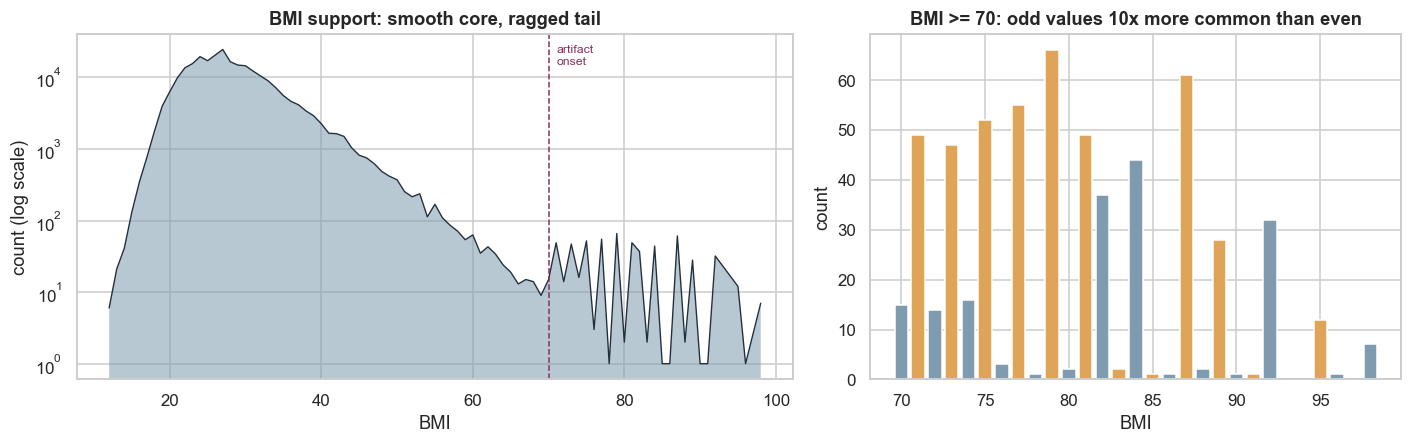

BMI 55-69 (thinning) : 758 rows (0.30% of sample)
BMI >= 70 (artifact) : 599 rows (0.24% of sample)   BMI >= 80 : 281   BMI = 98 : 7
BMI < 16 : 200


In [15]:
vc = raw.BMI.value_counts().sort_index()
tail = vc.loc[70:]
tail_parity = np.where(tail.index % 2 == 1, "odd", "even")
odd_med  = np.median(tail.values[tail_parity == "odd"])
even_med = np.median(tail.values[tail_parity == "even"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
ax.fill_between(vc.index, vc.values, color=C_NO, alpha=.55, lw=0)
ax.plot(vc.index, vc.values, color="#22303c", lw=.9)
ax.set_yscale("log"); ax.set_xlabel("BMI"); ax.set_ylabel("count (log scale)")
ax.set_title("BMI support: smooth core, ragged tail")
ax.axvline(70, color=C_DIA, ls="--", lw=1)
ax.text(71, ax.get_ylim()[1] * .5, "artifact\nonset", color=C_DIA, fontsize=8, va="center")

ax = axes[1]
ax.bar(tail.index, tail.values, width=.8,
       color=[C_PRE if p == "odd" else C_NO for p in tail_parity])
ax.set_xlabel("BMI"); ax.set_ylabel("count")
ax.set_title(f"BMI >= 70: odd values {odd_med/even_med:.0f}x more common than even")
plt.tight_layout(); plt.show()

print(f"BMI 55-69 (thinning) : {raw.BMI.between(55, 69).sum():,} rows "
      f"({100*raw.BMI.between(55, 69).mean():.2f}% of sample)")
print(f"BMI >= 70 (artifact) : {(raw.BMI>=70).sum():,} rows "
      f"({100*(raw.BMI>=70).mean():.2f}% of sample)   BMI >= 80 : {(raw.BMI>=80).sum():,}   "
      f"BMI = 98 : {(raw.BMI==98).sum():,}")
print(f"BMI < 16 : {(raw.BMI<16).sum():,}")

The tail has two regimes. From the mid-50s to about 70 it simply thins: every
integer value is still present and the counts fall away smoothly. That is a sparse
tail, not a corrupted one, and those rows are kept as real.

Above 70 the pattern changes. Odd BMI values become far more common than even ones
and carry most of the remaining mass, so the variable is no longer recording a
measurement there and most likely it is being back-calculated from height and weight
that were themselves rounded, though the exact mechanism is unclear. Very few rows
sit above 70, but in a variance-sensitive method they carry leverage far out of
proportion to their number. 

### Recoding BMI

Two derived columns come out of this. `bmi_cat` bins BMI at the standard WHO
cut-points, folding everything at or above 40 into a single "obese III" class,
which handles both the ragged tail and the non-linear risk gradient in one step.
`bmi_winsor` caps the raw number at 70 for places a numeric BMI is still needed,
pulling the digit artifact back to the edge of the believable range without
dropping any rows. The original, uncapped `BMI` column is kept alongside both.

In [16]:
BMI_BINS   = [0, 18.5, 25, 30, 35, 40, 99]
BMI_LABELS = ["underweight", "normal", "overweight", "obese I", "obese II", "obese III"]

raw["bmi_cat"]    = pd.cut(raw.BMI, BMI_BINS, right=False, labels=BMI_LABELS)
raw["bmi_winsor"] = np.minimum(raw.BMI, 70)

summary = raw.groupby("bmi_cat", observed=True).agg(
    n=("BMI", "size"), bmi_min=("BMI", "min"), bmi_max=("BMI", "max"),
    prevalence=(TARGET, "mean"))
summary["share %"]      = (100 * summary.n / len(raw)).round(2)
summary["prevalence %"] = (100 * summary.prevalence).round(2)

display(summary[["n", "share %", "bmi_min", "bmi_max", "prevalence %"]])

print(f"rows winsorised by the BMI 70 cap : {(raw.BMI > 70).sum():,}")
print("bmi_cat and bmi_winsor are now available for the rest of the notebook.")

,n,share %,bmi_min,bmi_max,prevalence %
bmi_cat,,,,,
underweight,3127,1.230,12.000,18.000,5.400
normal,68953,27.180,19.000,24.000,5.700
overweight,93749,36.960,25.000,29.000,11.400
obese I,53451,21.070,30.000,34.000,19.230
obese II,20663,8.150,35.000,39.000,27.440
obese III,13737,5.420,40.000,98.000,33.540


rows winsorised by the BMI 70 cap : 584
bmi_cat and bmi_winsor are now available for the rest of the notebook.


## 4.4 Structural Issues: Zero-Inflation and Near-Constant Columns

Two further problems are not "dirty data" in the usual sense, but will mislead
anyone who summarizes these columns with a mean and standard deviation.

In [17]:
# Zero-inflation in the two 30-day count variables
for v in ["MentHlth", "PhysHlth"]:
    zeros = 100 * (raw[v] == 0).mean()
    at30  = 100 * (raw[v] == 30).mean()
    print(f"{v}: {zeros:.1f}% are exactly 0 | {at30:.1f}% are exactly 30 "
          f"| mean = {raw[v].mean():.2f}, median = {raw[v].median():.0f}")

MentHlth: 69.3% are exactly 0 | 4.8% are exactly 30 | mean = 3.18, median = 0
PhysHlth: 63.1% are exactly 0 | 7.6% are exactly 30 | mean = 4.24, median = 0


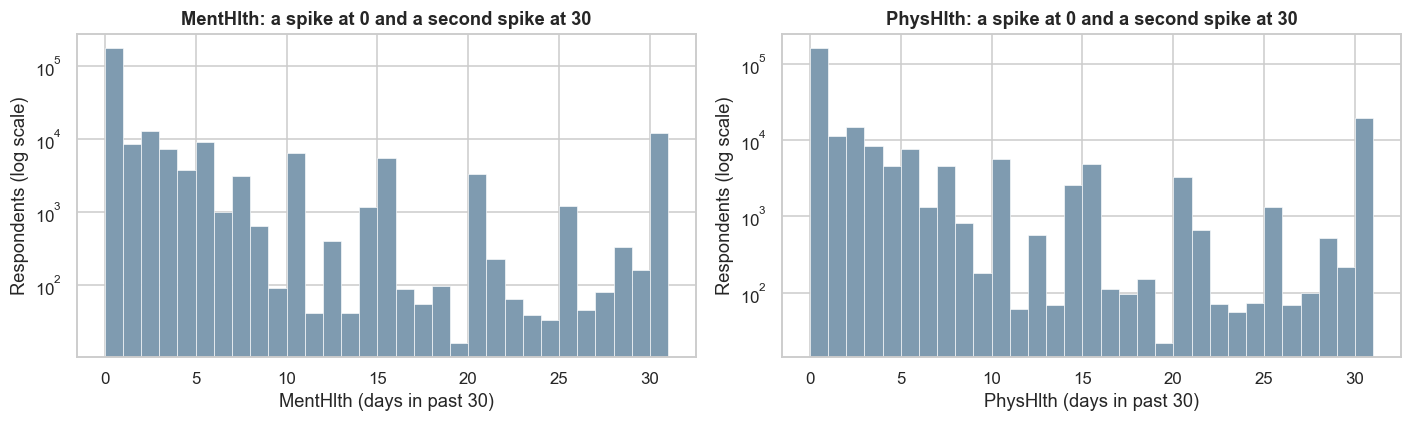

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, v in zip(axes, ["MentHlth", "PhysHlth"]):
    ax.hist(raw[v], bins=range(0, 32), color=C_NO, edgecolor="white", linewidth=0.4)
    ax.set_yscale("log")
    ax.set_xlabel(f"{v} (days in past 30)")
    ax.set_ylabel("Respondents (log scale)")
    ax.set_title(f"{v}: a spike at 0 and a second spike at 30")
plt.tight_layout()
plt.show()

Both variables are zero-inflated with a secondary spike at 30. Roughly
two-thirds of respondents report zero bad days, and a small but distinct group
reports that every day was bad.

This is not a continuous distribution and should not be summarized as one. The
mean of `MentHlth` sits in a valley between two clusters, describing a respondent
who barely exists. How we deal with it: treat these as categorical bands
(0 days / 1-13 / 14+ / all 30) rather than as continuous counts where that
distinction matters, and test whether the bands separate the classes.

In [19]:
# Near-constant columns carry little information on their own
binary_cols = [c for c in FEATURES if raw[c].nunique() == 2 and c != "Sex"]

balance = pd.DataFrame({
    "pct_1": (100 * raw[binary_cols].mean()).round(1),
}).sort_values("pct_1")
balance["minority_share"] = balance.pct_1.where(balance.pct_1 < 50, 100 - balance.pct_1)
balance["flag"] = np.where(balance.minority_share < 10, "near-constant", "")
balance

,pct_1,minority_share,flag
Stroke,4.100,4.100,near-constant
HvyAlcoholConsump,5.600,5.600,near-constant
NoDocbcCost,8.400,8.400,near-constant
HeartDiseaseorAttack,9.400,9.400,near-constant
DiffWalk,16.800,16.800,
HighChol,42.400,42.400,
HighBP,42.900,42.900,
Smoker,44.300,44.300,
Fruits,63.400,36.600,
PhysActivity,75.700,24.300,


Several variables have a minority class below 10% (`CholCheck`, `AnyHealthcare`,
`Stroke`, `HvyAlcoholConsump`, `NoDocbcCost`, `HeartDiseaseorAttack`). These are not
errors as they are genuinely rare conditions or near-universal behaviors. This means we will keep
all of them. Rare events can still be strongly predictive when they do occur, and
several combine into useful composite features. A low minority share
is a reason to check a variable, not a reason to drop it.

## 4.5 Cleaning Summary

| Issue | Finding | Decision | Rationale |
|---|---|---|---|
| Missing values | Zero, but only because incomplete records were pre-removed | Document the narrowed population | No imputation possible; the bias is in what was already dropped |
| Duplicate rows | ~9% of rows are exact duplicates | **Keep all** (Decision #3) | Removing them inflates the apparent diabetes rate by preferentially deleting healthy profiles, confirmed by both a headline shift and a fuller profile comparison |
| BMI tail | Digit-rounding artifact appears above BMI 70 | **Winsorise at 70 for numeric use; keep the original column** (Decision #2) | The cutoff follows a diagnosed artifact, not an arbitrary percentile |
| Zero-inflation | `MentHlth`, `PhysHlth` both spike at 0 and at 30 | **Band into categories where that distinction matters** | Mean is uninterpretable between two clusters |
| Near-constant cols | Several columns with < 10% minority class | **Keep** | Rare but predictive; useful in composites |
| Label validity | Measures diagnosis, not disease (Decision #7) | **Document; withhold access variables from risk models; model the undiagnosed separately** | Cannot be fixed in the data, only reported and worked around |

No rows were deleted. Two derived columns were added (`bmi_cat`, `bmi_winsor`), and
the target was recoded to `Diabetes_binary` per Decision #1.

# 5. Sample Representativeness — Comparing to the US Population

Section 1 flagged two facts about this file: the BRFSS design weights are absent,
and about 43% of the original respondents were removed by a complete-case filter.
Together they mean the sample's demographic marginals need not match the US adult
population, and wherever they do not, every prevalence figure in this notebook is
shifted away from the population value.

This section measures that gap on the three demographic axes the file carries:
**age**, **household income**, and **educational attainment**. The reference is
the **2015 American Community Survey 1-year** release, pulled from the Census API
(`B01001` for age, `B19001` for household income, `B15003` for education), with
each set of ACS brackets collapsed onto the BRFSS coding.

The BRFSS and ACS figures misalign on three points. BRFSS `Income` is reported by
each adult about their household, whereas the ACS distribution is over households,
so the two do not share exactly the same base. ACS educational attainment is
tabulated for ages 25 and over, against a BRFSS frame of 18 and over. Finally, the
BRFSS income and education non-responses were dropped before this CSV was written,
while the ACS imputes them. ACS margins of error are negligible at national scale
and are not shown.

The API pull lives in `scripts/build_census_reference.py`, outside this notebook.
It fetches the three ACS tables, applies the bracket crosswalks, and writes
`Lab1/cache/census_2015_reference.json`. The next cell hardcodes the figures from
that file, so this section needs no network access and no Census API key to run.
To refresh the reference, get a free key at
<https://api.census.gov/data/key_signup.html> (the API has required one since 2025)
and run:

```
CENSUS_API_KEY=your_key python scripts/build_census_reference.py
```

then paste the regenerated values into the next cell.

In [20]:
AGE_LAB = ["18-24","25-29","30-34","35-39","40-44","45-49","50-54",
           "55-59","60-64","65-69","70-74","75-79","80+"]
INC_LAB = ["<$10k","$10-15k","$15-20k","$20-25k","$25-35k","$35-50k","$50-75k","$75k+"]
EDU_LAB = ["Never\nattended","Elementary","Some HS","HS grad",
           "Some college /\ntechnical","College grad"]

def wilson(k, n, z=1.96):
    """Wilson score interval for a binomial proportion k/n."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))

In [21]:
# Hardcoded from cache/census_2015_reference.json (2015 ACS 1-year estimates:
# B01001 age, B19001 household income, B15003 education), collapsed onto the
# BRFSS band scheme by scripts/build_census_reference.py. See the prose above
# for how to regenerate this file and why it is embedded rather than read live.
ref = {
    "age": {
        "labels": [
            "18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64",
            "65-69", "70-74", "75-79", "80+"
        ],
        "counts": [
            31341948, 22292402, 21605430, 20497148, 20306982, 20825489,
            22310091, 21590716, 19286425, 16077656, 11509611, 8141322,
            12003891,
        ],
        "base": 247789111,
        "share": [
            0.12648638139712282, 0.08996522046523667, 0.08719281453816588,
            0.08272013212073714, 0.081952681124878, 0.0840452145615067,
            0.09003660778297881, 0.08713343339772506, 0.07783402959946856,
            0.06488443311780556, 0.04644922028070878, 0.03285585055430462,
            0.0484439810593614,
        ],
    },
    "income": {
        "labels": [
            "<10k", "10-15k", "15-20k", "20-25k", "25-35k", "35-50k", "50-75k", ">=75k"
        ],
        "counts": [
            8104547, 5861099, 5903590, 6185673, 11602462, 15642652,
            21068316, 43839911,
        ],
        "base": 118208250,
        "share": [
            0.06856160208784073, 0.049582825225819686, 0.04994228406223762,
            0.052328606505891086, 0.09815272622680735, 0.13233130513310196,
            0.17823050421607628, 0.3708701465422253,
        ],
    },
    "education": {
        "labels": [
            "never attended", "elementary", "some HS", "HS grad", "some college", "college grad"
        ],
        "counts": [
            3208900, 8779139, 15838087, 59662981, 62716503, 66241553,
        ],
        "base": 216447163,
        "share": [
            0.014825327140000445, 0.04056019436022823, 0.07317299418703861,
            0.27564686075372585, 0.2897543314069679, 0.306040292152039,
        ],
    },
}

for dim in ("age", "income", "education"):
    assert abs(sum(ref[dim]["share"]) - 1.0) < 1e-9, dim

print(f"census reference [hardcoded]   US pop 18+ {ref['age']['base']:,}   "
      f"households {ref['income']['base']:,}   US pop 25+ {ref['education']['base']:,}")

census reference [hardcoded]   US pop 18+ 247,789,111   households 118,208,250   US pop 25+ 216,447,163


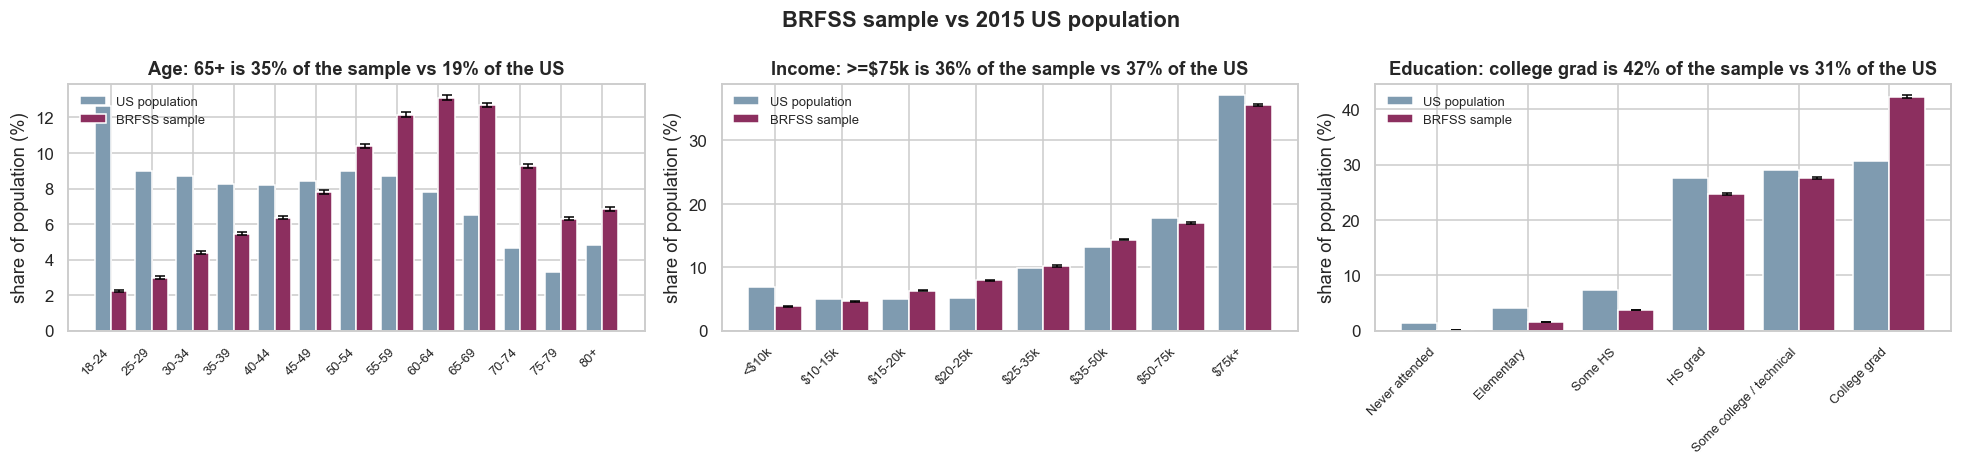

In [22]:
BANDS = {"age": (range(1, 14), AGE_LAB), "income": (range(1, 9), INC_LAB),
         "education": (range(1, 7), EDU_LAB)}
COLS  = {"age": "Age", "income": "Income", "education": "Education"}
HEAD  = {"age": (slice(9, 13), "65+"), "income": (slice(7, 8), ">=$75k"),
         "education": (slice(5, 6), "college grad")}


def _sample_share(dim):
    rng = BANDS[dim][0]
    cnt = raw[COLS[dim]].value_counts().reindex(rng, fill_value=0).to_numpy()
    return cnt, cnt / cnt.sum()


fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
for ax, dim in zip(axes, ("age", "income", "education")):
    labs   = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us     = np.array(ref[dim]["share"])
    cnt, samp = _sample_share(dim)
    lo, hi = map(np.array, zip(*[wilson(int(k), int(cnt.sum())) for k in cnt]))
    x = np.arange(len(labs)); w = .4
    ax.bar(x - w/2, 100*us,   w, color=C_NO,  label="US population")
    ax.bar(x + w/2, 100*samp, w, color=C_DIA, label="BRFSS sample",
           yerr=[100*(samp - lo), 100*(hi - samp)],
           error_kw=dict(ecolor="black", lw=1, capsize=3))
    ax.set_xticks(x); ax.set_xticklabels(labs, rotation=45, ha="right", fontsize=8.5)
    ax.set_ylabel("share of population (%)")
    sl, name = HEAD[dim]
    ax.set_title(f"{dim.capitalize()}: {name} is {100*samp[sl].sum():.0f}% of the "
                 f"sample vs {100*us[sl].sum():.0f}% of the US")
    ax.legend(fontsize=8.5, frameon=False)
fig.suptitle("BRFSS sample vs 2015 US population", fontweight="bold")
plt.tight_layout(); plt.show()

In [23]:
rows_, tvd = [], {}
for dim in ("age", "income", "education"):
    labs   = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us     = np.array(ref[dim]["share"])
    cnt, samp = _sample_share(dim)
    lo, hi = zip(*[wilson(int(k), int(cnt.sum())) for k in cnt])
    tvd[dim] = 0.5 * np.abs(samp - us).sum()
    for i, lab in enumerate(labs):
        rows_.append({"dimension": dim, "band": lab,
                      "US %": 100*us[i], "sample %": 100*samp[i],
                      "diff (pts)": 100*(samp[i] - us[i]),
                      "sample 95% CI": f"[{100*lo[i]:.2f}, {100*hi[i]:.2f}]"})

diff_table = pd.DataFrame(rows_)
display(diff_table.round(2))

print("total variation distance from a representative sample (0 = identical, 1 = disjoint):")
for dim, v in tvd.items():
    print(f"  {dim:9s} {v:.3f}")

,dimension,band,US %,sample %,diff (pts),sample 95% CI
0,age,18-24,12.650,2.250,-10.400,"[2.19, 2.31]"
1,age,25-29,9.000,3.000,-6.000,"[2.93, 3.06]"
2,age,30-34,8.720,4.380,-4.330,"[4.31, 4.47]"
3,age,35-39,8.270,5.450,-2.820,"[5.36, 5.54]"
4,age,40-44,8.200,6.370,-1.830,"[6.27, 6.46]"
5,age,45-49,8.400,7.810,-0.590,"[7.71, 7.92]"
6,age,50-54,9.000,10.370,1.370,"[10.25, 10.49]"
7,age,55-59,8.710,12.150,3.440,"[12.03, 12.28]"
8,age,60-64,7.780,13.100,5.320,"[12.97, 13.24]"
9,age,65-69,6.490,12.690,6.200,"[12.56, 12.82]"


total variation distance from a representative sample (0 = identical, 1 = disjoint):
  age       0.260
  income    0.055
  education 0.117


# 6. The Target Variable


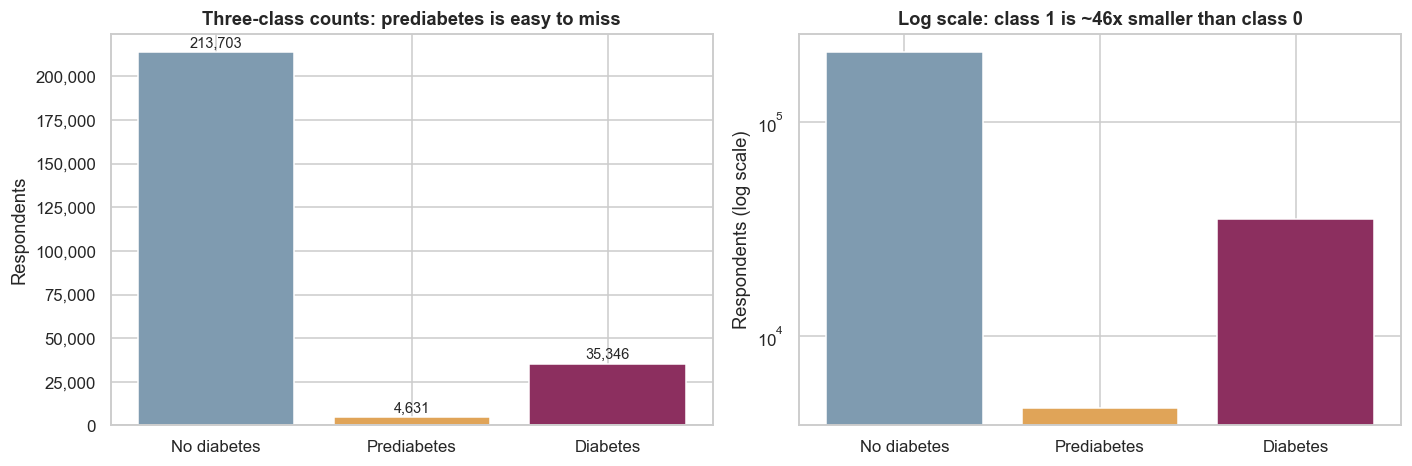

class 1 (prediabetes) is 46x smaller than class 0


In [24]:
counts_012 = raw.Diabetes_012.value_counts().sort_index()
labels_012 = ["No diabetes", "Prediabetes", "Diabetes"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

bars = axes[0].bar(labels_012, counts_012.values, color=PALETTE_012, edgecolor="white")
axes[0].set_ylabel("Respondents")
axes[0].set_title("Three-class counts: prediabetes is easy to miss")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for b, v in zip(bars, counts_012.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 3000, f"{v:,}", ha="center", fontsize=9.5)

axes[1].bar(labels_012, counts_012.values, color=PALETTE_012, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_ylabel("Respondents (log scale)")
axes[1].set_title("Log scale: class 1 is ~46x smaller than class 0")

plt.tight_layout()
plt.show()

print(f"class 1 (prediabetes) is {counts_012[0]/counts_012[1]:.0f}x smaller than class 0")

On a linear
scale the prediabetes class is barely readable, and the log-scaled panel confirms
it because roughly 46 times fewer respondents than the no-diabetes class. Beyond size,
the CDC estimates roughly a third of US adults have prediabetes, but only ~1.8% of
this sample is coded as such: that gap is diagnostic access, not biology. Most
people with prediabetes have never been told, so the class is not just rare, it
is unreliably labeled which is a second  reason to
prefer the binary framing.

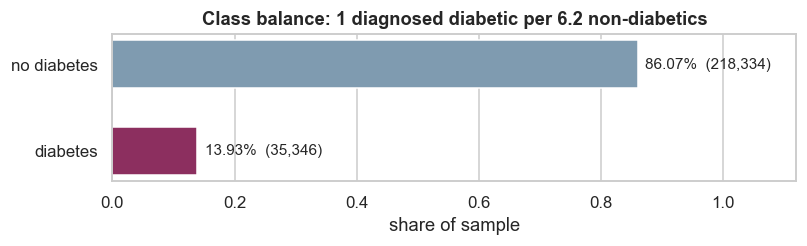

positive class: 35,346 rows (13.93%)
accuracy of a model that always predicts 'no diabetes': 86.07%


In [25]:
prev = raw[TARGET].mean()

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.barh(["diabetes", "no diabetes"], [prev, 1-prev],
        color=[C_DIA, C_NO], height=.55)
for i, v in enumerate([prev, 1-prev]):
    ax.text(v + .012, i, f"{v*100:.2f}%  ({int(v*len(raw)):,})", va="center", fontsize=10)
ax.set_xlim(0, 1.12); ax.set_xlabel("share of sample")
ax.set_title(f"Class balance: 1 diagnosed diabetic per {(1-prev)/prev:.1f} non-diabetics")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"positive class: {raw[TARGET].sum():,.0f} rows ({100*prev:.2f}%)")
print(f"accuracy of a model that always predicts 'no diabetes': {100*(1-prev):.2f}%")

### Interpretation

Under the binary framing, diagnosed diabetes is about 13.9% of the sample.
the sample skews older than the general population, so
this figure overstates the national rate of *diagnosed* diabetes, and the
diagnosis-vs-disease gap means it understates the true rate of the underlying
condition. Both biases point the same direction, away from this number being a
population estimate.

Three consequences follow, and both feed directly into Section 15:

1. The ~86% majority sets the accuracy floor. Any model must beat that to be
   worth anything.
2. This is a hard classification problem even before modeling starts because the
   positive class is a small minority of a sample that is itself not
   representative of the population it's drawn from.
3. The gap between this number and the true prevalence is the subject of
   Section 15.2.

# 7. Distributions of Key Attributes

## 7.1 BMI — diabetic median sits higher, but the groups overlap heavily

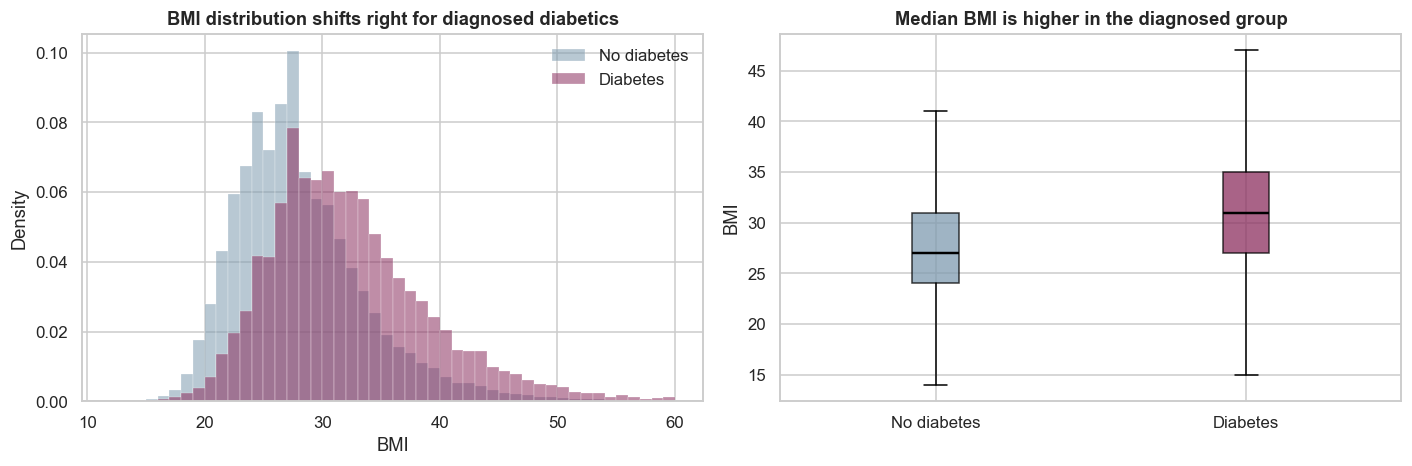

                 median   mean   std
Diabetes_binary                     
0                27.000 27.810 6.290
1                31.000 31.940 7.360


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Overlaid densities let the (very differently-sized) groups be compared directly
for is_dia, lab, col in zip([0, 1], ["No diabetes", "Diabetes"], [C_NO, C_DIA]):
    subset = raw.loc[raw[TARGET] == is_dia, "BMI"]
    axes[0].hist(subset, bins=range(12, 61), density=True, alpha=0.55,
                 label=lab, color=col, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Density")
axes[0].set_title("BMI distribution shifts right for diagnosed diabetics")
axes[0].legend(frameon=False)

box_data = [raw.loc[raw[TARGET] == c, "BMI"] for c in [0, 1]]
bp = axes[1].boxplot(box_data, tick_labels=["No diabetes", "Diabetes"], patch_artist=True,
                      showfliers=False, medianprops=dict(color="black", linewidth=1.6))
for patch, col in zip(bp["boxes"], [C_NO, C_DIA]):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
axes[1].set_ylabel("BMI")
axes[1].set_title("Median BMI is higher in the diagnosed group")

plt.tight_layout()
plt.show()

print(raw.groupby(TARGET)["BMI"].agg(["median", "mean", "std"]).round(2).to_string())

BMI is the only true continuous variable in the dataset, so a density
histogram is appropriate; normalizing to density lets two very differently-sized
groups be compared on the same axes (raw counts would make the diabetic group
invisible). The box plot compresses each group to its median and quartiles;
outlier points are suppressed since with 253,680 rows they form an unreadable
smear.

### Interpretation

The diabetic distribution is shifted right at the median. The shift is in the
body of the distribution, not driven by the extreme tail and BMI carries signal
across its normal range, not only among the severely obese. The overlap between
groups is still substantial: plenty of people with a moderate BMI have diabetes and
plenty with a high BMI do not. BMI is a genuine risk factor but nowhere near
deterministic on its own.

## 7.2 General Health

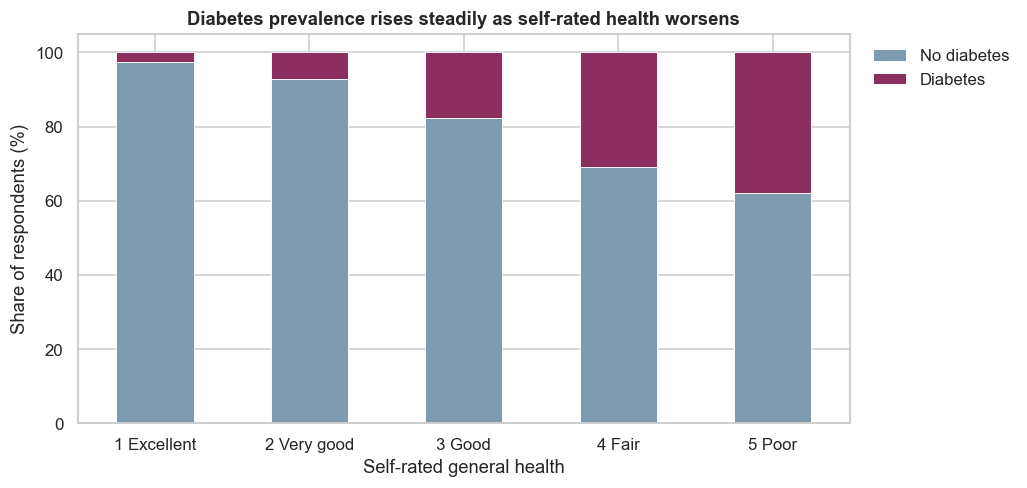

,No diabetes,Diabetes
1 Excellent,97.500,2.500
2 Very good,92.800,7.200
3 Good,82.200,17.800
4 Fair,69.000,31.000
5 Poor,62.100,37.900


In [27]:
gen = pd.crosstab(raw.GenHlth, raw[TARGET], normalize="index") * 100
gen.columns = ["No diabetes", "Diabetes"]
gen.index = ["1 Excellent", "2 Very good", "3 Good", "4 Fair", "5 Poor"]

ax = gen.plot(kind="bar", stacked=True, figsize=(9.5, 4.6),
              color=[C_NO, C_DIA], edgecolor="white", linewidth=0.6)
ax.set_xlabel("Self-rated general health")
ax.set_ylabel("Share of respondents (%)")
ax.set_title("Diabetes prevalence rises steadily as self-rated health worsens")
ax.legend(title="", frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gen.round(1)

### Interpretation

This is the strongest single relationship in the dataset by the Cramér's V ranking. The diabetes rate climbs sharply from those rating their health
excellent to those rating it poor but this variable needs care, because
self-rated health is partly a consequence of having diabetes, not only a
predictor of it. Someone managing diabetes and its complications will rate their
health worse partly because of the diabetes, and it also correlates strongly with
poor physical health days and walking difficulty, so much of what it measures is
captured elsewhere too.

It is an excellent screening signal because someone rating their health poorly
warrants attention but a poor causal one. It cannot support a claim that
improving how someone feels about their health would reduce their diabetes risk.

## 7.3 Age

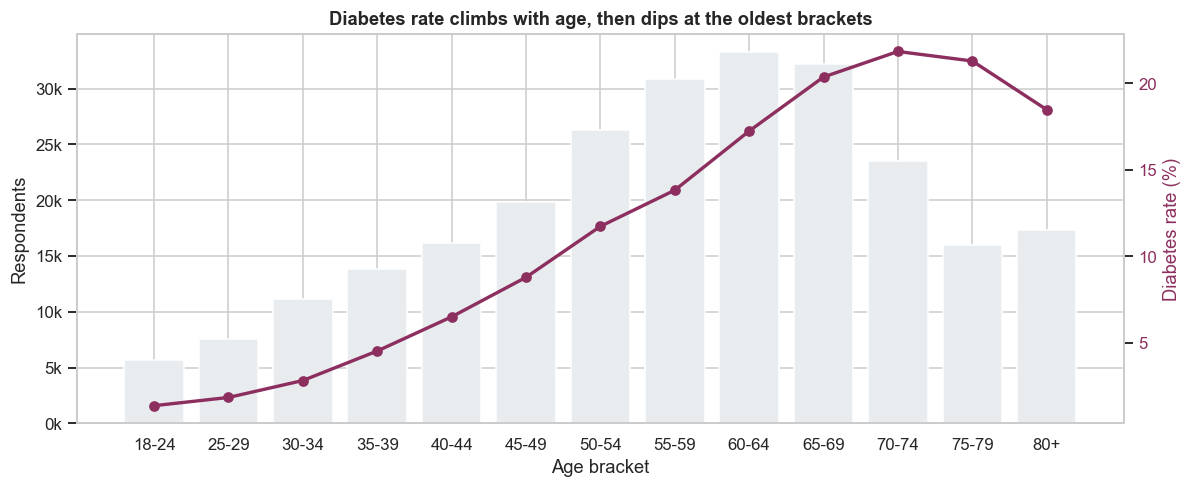

,pct_diabetes,pct_prediabetes,n
18-24,1.400,0.400,5700.000
25-29,1.800,0.700,7598.000
30-34,2.800,0.600,11123.000
35-39,4.500,1.000,13823.000
40-44,6.500,1.000,16157.000
45-49,8.800,1.600,19819.000
50-54,11.700,1.600,26314.000
55-59,13.800,1.800,30832.000
60-64,17.200,2.100,33244.000
65-69,20.400,2.200,32194.000


In [28]:
age_labels = ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49", "50-54",
              "55-59", "60-64", "65-69", "70-74", "75-79", "80+"]

age_rate = raw.groupby("Age").apply(
    lambda g: pd.Series({
        "pct_diabetes":    100 * (g[TARGET] == 1).mean(),
        "pct_prediabetes": 100 * (g.Diabetes_012 == 1).mean(),
        "n": len(g),
    }), include_groups=False)
age_rate.index = age_labels

fig, ax1 = plt.subplots(figsize=(11, 4.6))
ax1.bar(age_rate.index, age_rate.n, color="#e8ecef", edgecolor="white",
        label="Respondents (left axis)")
ax1.set_ylabel("Respondents")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax1.set_xlabel("Age bracket")

ax2 = ax1.twinx()
ax2.plot(age_rate.index, age_rate.pct_diabetes, marker="o", color=C_DIA,
         linewidth=2.2, label="Diagnosed diabetes rate")
ax2.set_ylabel("Diabetes rate (%)", color=C_DIA)
ax2.tick_params(axis="y", labelcolor=C_DIA)
ax2.grid(False)

ax1.set_title("Diabetes rate climbs with age, then dips at the oldest brackets")
plt.tight_layout()
plt.show()

age_rate.round(1)

### Interpretation

The diabetes rate rises steeply and monotonically through the 70-74 bracket, then
falls in the oldest brackets. That final dip is almost certainly not a real
decline in risk:

1. Survivor bias. Diabetes raises mortality, so people who developed it earlier
   are less likely to reach the oldest brackets; the surviving population there is
   selectively healthier.
2. Survey coverage. BRFSS is a telephone survey of non-institutionalized
   adults. The sickest oldest respondents are disproportionately in nursing homes
   and never sampled.

## 7.4 Binary health indicators

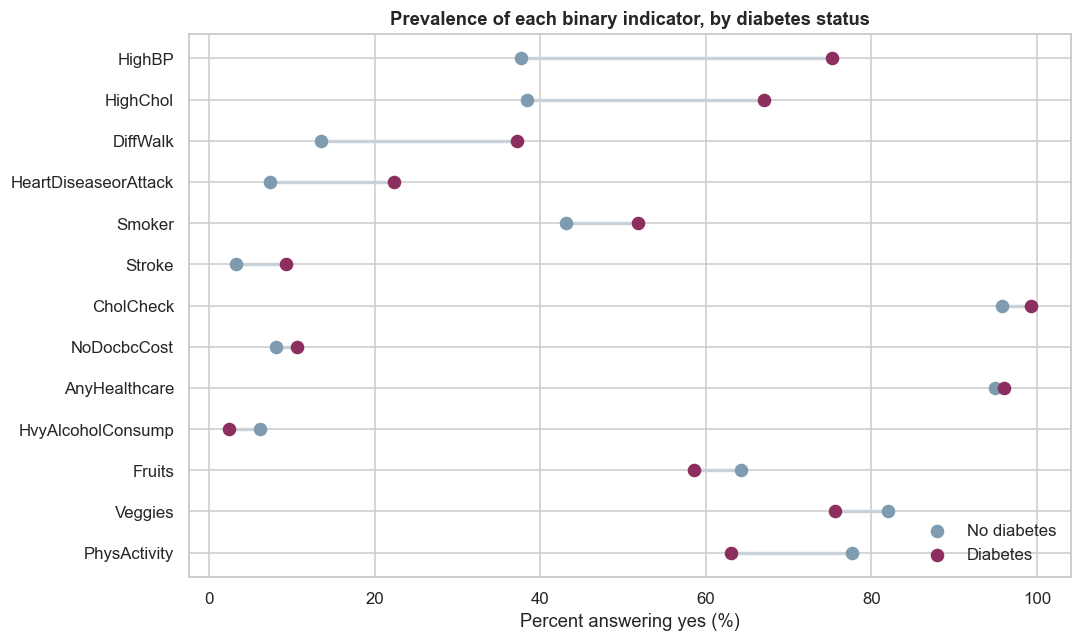

,No diabetes,Diabetes,gap
PhysActivity,77.700,63.100,-14.600
Veggies,82.000,75.600,-6.400
Fruits,64.200,58.500,-5.700
HvyAlcoholConsump,6.100,2.400,-3.800
AnyHealthcare,95.000,96.000,1.000
NoDocbcCost,8.100,10.600,2.500
CholCheck,95.800,99.300,3.500
Stroke,3.200,9.200,6.000
Smoker,43.100,51.800,8.700
HeartDiseaseorAttack,7.300,22.300,15.000


In [29]:
binary_vars = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
               "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
               "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk"]

rates = pd.DataFrame({
    "No diabetes": [100 * raw.loc[raw[TARGET] == 0, v].mean() for v in binary_vars],
    "Diabetes":    [100 * raw.loc[raw[TARGET] == 1, v].mean() for v in binary_vars],
}, index=binary_vars)
rates["gap"] = rates["Diabetes"] - rates["No diabetes"]
rates = rates.sort_values("gap")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(rates))
ax.hlines(y, rates["No diabetes"], rates["Diabetes"], color="#c9d2d8", linewidth=2.2)
ax.scatter(rates["No diabetes"], y, color=C_NO, s=62, label="No diabetes", zorder=3)
ax.scatter(rates["Diabetes"], y, color=C_DIA, s=62, label="Diabetes", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(rates.index)
ax.set_xlabel("Percent answering yes (%)")
ax.set_title("Prevalence of each binary indicator, by diabetes status")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

rates.round(1)

### Interpretation

`HighBP` and `HighChol` show the widest gaps of the binary indicators. `CholCheck` and `AnyHealthcare` are, by contrast, higher
among diagnosed diabetics through reverse causation. Someone with
diabetes is screened and covered because of the diagnosis process, not the other
way around.

In [30]:
# How two of the strongest risk factors combine
combo = (raw.assign(is_dia=raw[TARGET])
         .groupby(["HighBP", "HighChol"])
         .agg(rate=("is_dia", lambda s: 100 * s.mean()), n=("is_dia", "size")))
combo.index = pd.MultiIndex.from_tuples(
    [("No high BP", "No high chol"), ("No high BP", "High chol"),
     ("High BP", "No high chol"), ("High BP", "High chol")])
combo.round(1)

rate       n
No high BP No high chol  4.200  101920
           High chol    10.400   42931
High BP    No high chol 16.700   44169
           High chol    29.700   64660

### Interpretation

Someone with
neither condition has a low diabetes rate, and someone with both has a
much higher one which is well beyond what either condition shows on its own. Having just
one lands in between. High blood pressure is clearly the stronger of the two
individually. These two are not redundant with each other; we keep both, and their
interaction may add signal a purely additive model would miss.

## 7.5 Income and Education 

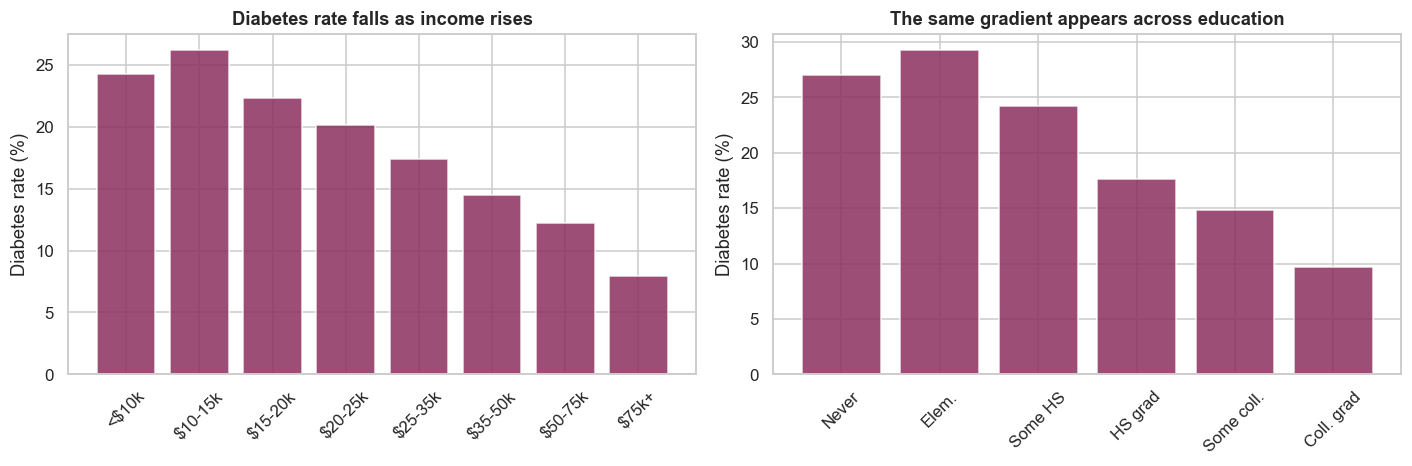

Income gradient: 24.3% (lowest) -> 8.0% (highest)
Education gradient: 27.0% (lowest) -> 9.7% (highest)


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

inc_labels = ["<$10k", "$10-15k", "$15-20k", "$20-25k", "$25-35k", "$35-50k", "$50-75k", "$75k+"]
inc = raw.groupby("Income").apply(
    lambda g: 100 * (g[TARGET] == 1).mean(), include_groups=False)
axes[0].bar(inc_labels, inc.values, color=C_DIA, alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Diabetes rate (%)")
axes[0].set_title("Diabetes rate falls as income rises")
axes[0].tick_params(axis="x", rotation=45)

edu_labels = ["Never", "Elem.", "Some HS", "HS grad", "Some coll.", "Coll. grad"]
edu = raw.groupby("Education").apply(
    lambda g: 100 * (g[TARGET] == 1).mean(), include_groups=False)
axes[1].bar(edu_labels, edu.values, color=C_DIA, alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_title("The same gradient appears across education")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Income gradient:", f"{inc.iloc[0]:.1f}% (lowest) -> {inc.iloc[-1]:.1f}% (highest)")
print("Education gradient:", f"{edu.iloc[0]:.1f}% (lowest) -> {edu.iloc[-1]:.1f}% (highest)")

### Interpretation

The gradient is steep but not perfectly monotonic as it tends to peak in the
second-lowest bracket rather than the very lowest, before falling steadily toward
the top bracket. Income and education correlate with each other too, so they are
substantially measuring the same underlying construct (socioeconomic position); a
model including both gets less additional information from the second than their
individual associations suggest.

The mechanism is not that low income causes diabetes directly, but that it runs
through food environment, time and facilities for physical activity, chronic
stress, and healthcare access. That last one cuts both ways: lower-income
respondents have less access to screening, so their true diabetes rate is probably
understated relative to higher-income respondents. The real
gradient is likely steeper than this chart shows.

# 8. Relationships Between Attributes

,feature,n_categories,chi2,p_value,cramers_v
0,GenHlth,5,22728.069,< 1e-300,0.299
1,HighBP,2,17562.446,< 1e-300,0.263
2,bmi_cat,6,13386.631,< 1e-300,0.230
3,DiffWalk,2,12092.320,< 1e-300,0.218
4,HighChol,2,10174.075,< 1e-300,0.200
5,Age,13,8795.051,< 1e-300,0.186
6,PhysHlth,31,8078.528,< 1e-300,0.178
7,HeartDiseaseorAttack,2,7971.156,< 1e-300,0.177
8,Income,8,7003.715,< 1e-300,0.166
9,Education,6,4027.112,< 1e-300,0.126


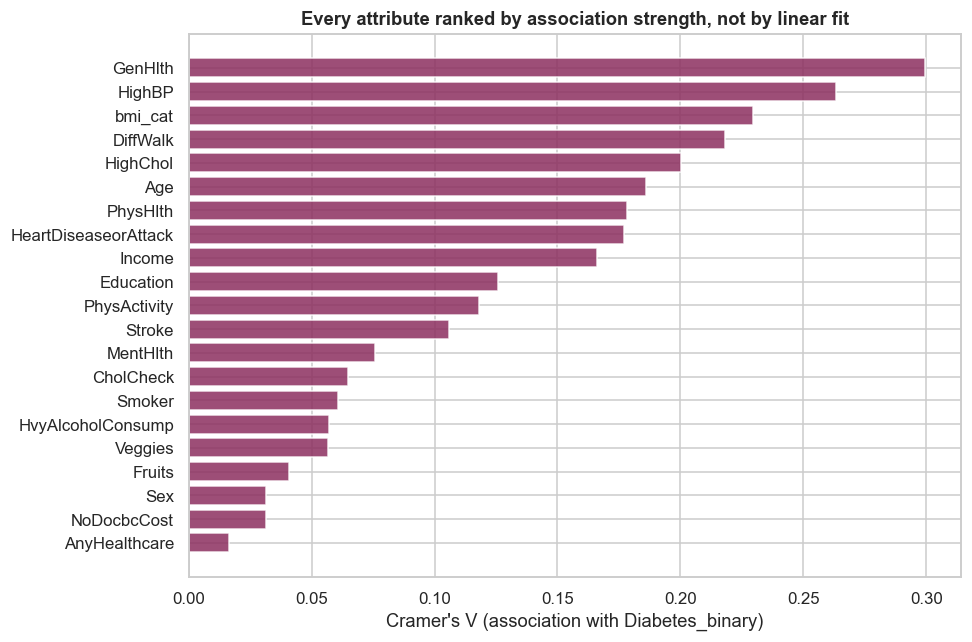

largest Cramer's V : 0.299  (feature: GenHlth)


In [32]:
# Cramer's V / chi-square for every feature against the binary target.
# bmi_cat stands in for BMI (a continuous variable would blow up the contingency
# table); MentHlth/PhysHlth are used as reported (31 levels each).
CORR_FEATURES = [c for c in FEATURES if c not in ("BMI", "bmi_winsor")] + ["bmi_cat"]

rows_ = []
for col in CORR_FEATURES:
    ct = pd.crosstab(raw[col], raw[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows_.append({
        "feature": col,
        "n_categories": raw[col].nunique(),
        "chi2": chi2,
        "p_value": p,
        "cramers_v": np.sqrt(chi2 / len(raw)),
    })

sig = pd.DataFrame(rows_).sort_values("cramers_v", ascending=False).reset_index(drop=True)
sig["p_value"] = sig.p_value.apply(lambda v: "< 1e-300" if v == 0 else f"{v:.2e}")

display(sig.round(4))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sig.feature[::-1], sig.cramers_v[::-1], color=C_DIA, alpha=0.85)
ax.set_xlabel("Cramer's V (association with Diabetes_binary)")
ax.set_title("Every attribute ranked by association strength, not by linear fit")
plt.tight_layout()
plt.show()

print(f"largest Cramer's V : {sig.cramers_v.max():.3f}  (feature: {sig.feature.iloc[0]})")

### Interpretation

No single variable dominates: even the top-ranked feature is a small-to-moderate
effect by conventional standards, and diabetes risk in this data is built from many
moderate signals rather than one strong predictor. That argues for methods that
combine weak signals well and against
expecting a simple rule to work.

A caution on p-values here: with 253,680 rows, even a trivially small effect
reaches significance. The Cramér's V ranking, not the p-value column, is what
should drive feature selection because every one of these associations would reach
significance at a small fraction of this sample size.

In [33]:
# Redundancy among predictors, not just with the target (Harvey's informal
# cross-check on the same idea Section 9's VIF formalizes)
num_feats = [c for c in FEATURES if c not in ("BMI", "bmi_winsor")]
pred_corr = raw[num_feats + ["bmi_winsor"]].apply(pd.to_numeric).corr().abs()
pairs = (pred_corr.where(np.triu(np.ones(pred_corr.shape, dtype=bool), k=1))
         .stack().sort_values(ascending=False).head(8))

print("Most strongly correlated predictor pairs (Pearson, as an intuitive cross-check only):")
for (a, b), v in pairs.items():
    print(f"  {a:<22} ~ {b:<22} r = {v:.2f}")

Most strongly correlated predictor pairs (Pearson, as an intuitive cross-check only):
  GenHlth                ~ PhysHlth               r = 0.52
  PhysHlth               ~ DiffWalk               r = 0.48
  GenHlth                ~ DiffWalk               r = 0.46
  Education              ~ Income                 r = 0.45
  GenHlth                ~ Income                 r = 0.37
  MentHlth               ~ PhysHlth               r = 0.35
  HighBP                 ~ Age                    r = 0.34
  DiffWalk               ~ Income                 r = 0.32


`GenHlth`, `PhysHlth`, and `DiffWalk` form a cluster, all measuring current
physical functioning, and `Education`-`Income` form another, both measuring
socioeconomic position. 

# 9. Multicollinearity

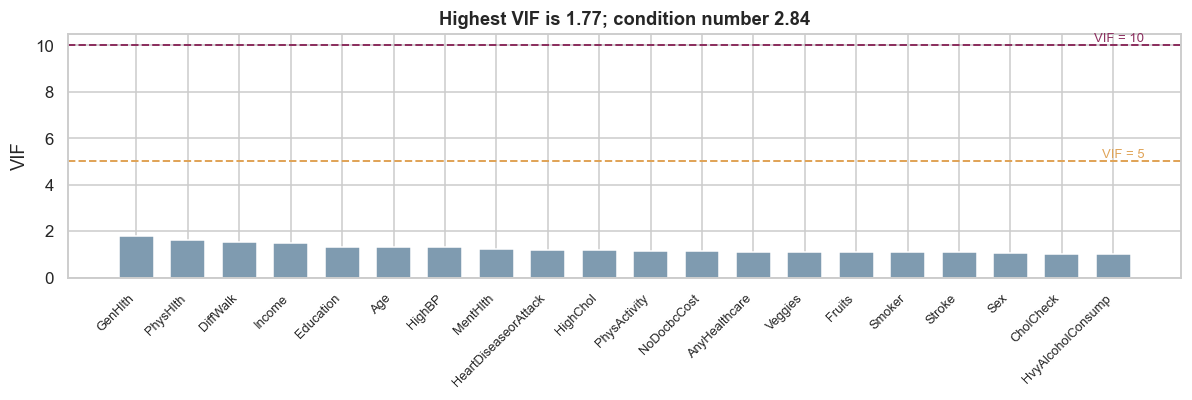

,GenHlth,PhysHlth,DiffWalk,Income,Education,Age,HighBP,MentHlth,HeartDiseaseorAttack,HighChol,PhysActivity,NoDocbcCost,AnyHealthcare,Veggies,Fruits,Smoker,Stroke,Sex,CholCheck,HvyAlcoholConsump
VIF,1.770,1.620,1.520,1.500,1.330,1.320,1.290,1.240,1.170,1.170,1.150,1.140,1.110,1.110,1.110,1.090,1.080,1.070,1.030,1.020


In [34]:
from sklearn.linear_model import LinearRegression

# VIF implemented directly (statsmodels is unavailable in this environment):
# VIF_i = 1 / (1 - R_i^2), where R_i^2 comes from regressing standardized
# feature i on all the other standardized features. This is the same quantity
# statsmodels.stats.outliers_influence.variance_inflation_factor computes.
VIF_FEATURES = [c for c in FEATURES if c not in ("BMI",)]  # use bmi_winsor instead of raw BMI

Xd = raw[VIF_FEATURES].apply(pd.to_numeric)
Xs = (Xd - Xd.mean()) / Xd.std()

vif_vals = {}
for col in Xs.columns:
    y_ = Xs[col].values
    X_ = Xs.drop(columns=[col]).values
    r2 = LinearRegression().fit(X_, y_).score(X_, y_)
    vif_vals[col] = 1.0 / (1.0 - r2) if r2 < 1.0 else np.inf

vif = pd.Series(vif_vals).sort_values(ascending=False)
sv = np.linalg.svd(Xs.values / np.sqrt(len(Xs)), compute_uv=False)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(range(len(vif)), vif.values, color=C_NO, width=.68)
ax.axhline(5,  color=C_PRE, ls="--", lw=1.3)
ax.axhline(10, color=C_DIA, ls="--", lw=1.3)
ax.text(len(vif)-.4, 5.15,  "VIF = 5",  ha="right", fontsize=8.6, color=C_PRE)
ax.text(len(vif)-.4, 10.15, "VIF = 10", ha="right", fontsize=8.6, color=C_DIA)
ax.set_xticks(range(len(vif)))
ax.set_xticklabels(vif.index, rotation=45, ha="right", fontsize=8.4)
ax.set_ylabel("VIF")
ax.set_title(f"Highest VIF is {vif.max():.2f}; condition number {sv.max()/sv.min():.2f}")
plt.tight_layout(); plt.show()

display(vif.round(2).to_frame("VIF").T)


# 10. Group-Wise Comparison

In [35]:
profile = raw.groupby("Diabetes_012").agg(
    n=("BMI", "size"),
    bmi_median=("BMI", "median"),
    bmi_mean=("BMI", "mean"),
    pct_highbp=("HighBP", lambda s: 100 * s.mean()),
    pct_highchol=("HighChol", lambda s: 100 * s.mean()),
    genhlth_mean=("GenHlth", "mean"),
    age_median=("Age", "median"),
    physhlth_mean=("PhysHlth", "mean"),
    pct_diffwalk=("DiffWalk", lambda s: 100 * s.mean()),
    income_median=("Income", "median"),
).round(2)
profile.index = ["No diabetes", "Prediabetes", "Diabetes"]
profile.T

,No diabetes,Prediabetes,Diabetes
n,213703.000,4631.000,35346.000
bmi_median,27.000,30.000,31.000
bmi_mean,27.740,30.720,31.940
pct_highbp,37.110,62.900,75.270
pct_highchol,37.920,62.080,67.010
genhlth_mean,2.370,2.980,3.290
age_median,8.000,9.000,10.000
physhlth_mean,3.580,6.350,7.950
pct_diffwalk,13.230,27.750,37.120
income_median,7.000,6.000,6.000


### Interpretation

Prediabetes sits consistently between the
other two classes on nearly every measure: BMI, blood pressure, cholesterol,
general health, walking difficulty. It is also why prediabetes would be hard to
classify as its own class because it is an intermediate zone, and with
only ~4,631 examples and unreliable labeling, a model has very little
to latch onto that isn't already captured by the other two classes. 

Note that `age_median` and `income_median` are bracket indices, not literal years
or dollars.

# 11. Proposed Feature Engineering Variables

We construct several candidate features and test whether they actually separate
the classes. 

In [36]:
d = raw.copy()

# 1. Clinical BMI categories rather than a raw number (superseded for general use
#    by bmi_cat from Section 4.3, reproduced here for side-by-side comparison)
d["BMI_category"] = d["bmi_cat"]

# 2. Banded poor-health days (handles the zero-inflation from Section 4.4)
def band_days(s):
    return pd.cut(s, bins=[-0.1, 0.5, 13.5, 29.5, 30.1],
                  labels=["0 days", "1-13", "14-29", "all 30"])

d["MentHlth_band"] = band_days(d.MentHlth)
d["PhysHlth_band"] = band_days(d.PhysHlth)

# 3. Count of cardiovascular comorbidities
d["CardioRisk"] = d[["HighBP", "HighChol", "HeartDiseaseorAttack", "Stroke"]].sum(axis=1)

# 4. Healthy-lifestyle score (kept deliberately, see the negative result below)
d["LifestyleScore"] = (d.PhysActivity + d.Fruits + d.Veggies
                        + (1 - d.Smoker) + (1 - d.HvyAlcoholConsump))

print(d[["BMI_category", "MentHlth_band", "CardioRisk", "LifestyleScore"]].head())

  BMI_category MentHlth_band  CardioRisk  LifestyleScore
0    obese III         14-29       2.000           2.000
1   overweight        0 days       0.000           2.000
2   overweight        all 30       2.000           3.000
3   overweight        0 days       1.000           5.000
4       normal          1-13       2.000           5.000


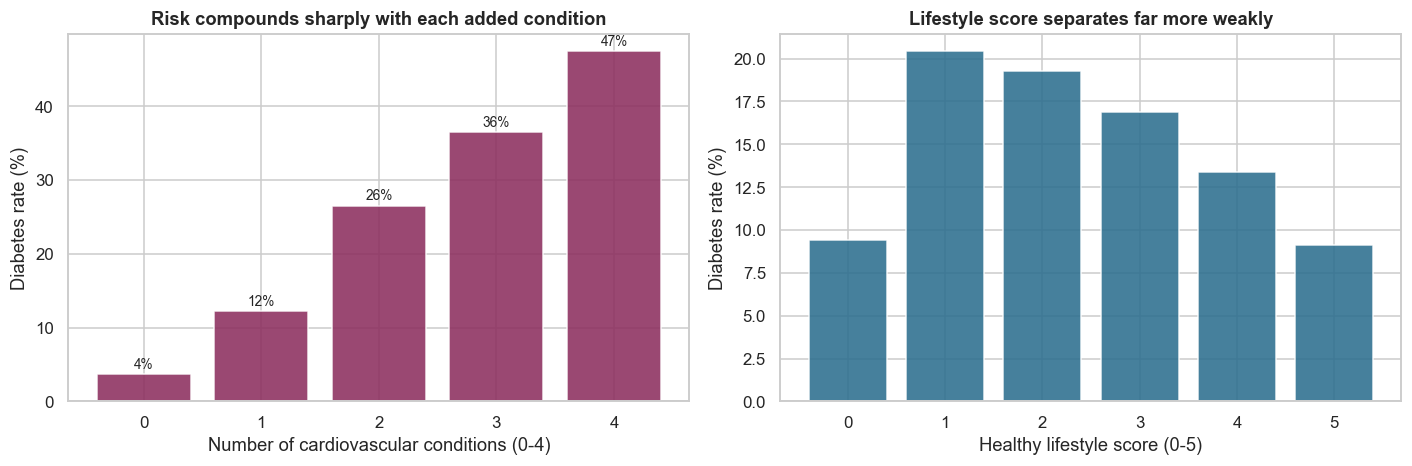

CardioRisk : {0.0: 3.7, 1.0: 12.2, 2.0: 26.5, 3.0: 36.4, 4.0: 47.4}
Lifestyle  : {0.0: 9.4, 1.0: 20.4, 2.0: 19.3, 3.0: 16.9, 4.0: 13.4, 5.0: 9.1}


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

cardio = d.groupby("CardioRisk").apply(
    lambda g: pd.Series({"rate": 100*g[TARGET].mean(), "n": len(g)}),
    include_groups=False)
axes[0].bar(cardio.index.astype(int).astype(str), cardio.rate,
            color=C_DIA, alpha=0.88, edgecolor="white")
axes[0].set_xlabel("Number of cardiovascular conditions (0-4)")
axes[0].set_ylabel("Diabetes rate (%)")
axes[0].set_title("Risk compounds sharply with each added condition")
for i, (r, n) in enumerate(zip(cardio.rate, cardio.n)):
    axes[0].text(i, r + 0.8, f"{r:.0f}%", ha="center", fontsize=9)

life = d.groupby("LifestyleScore").apply(
    lambda g: pd.Series({"rate": 100*g[TARGET].mean(), "n": len(g)}),
    include_groups=False)
axes[1].bar(life.index.astype(int).astype(str), life.rate,
            color="#2c6e8f", alpha=0.88, edgecolor="white")
axes[1].set_xlabel("Healthy lifestyle score (0-5)")
axes[1].set_ylabel("Diabetes rate (%)")
axes[1].set_title("Lifestyle score separates far more weakly")

plt.tight_layout()
plt.show()

print("CardioRisk :", cardio.rate.round(1).to_dict())
print("Lifestyle  :", life.rate.round(1).to_dict())

### Which engineered features are worth keeping

`CardioRisk` works well. The diabetes rate climbs sharply from zero conditions
to all four forming a cleaner, steeper gradient than any of its four components alone.
It also compresses four sparse binary columns into one ordinal variable, handling
the near-constant-column issue.

`LifestyleScore` works poorly. The gradient is shallow and not fully monotonic. Its components
are weak on their own (fruit and vegetable consumption both show only a very small
association with the target individually). Summing weak, crudely-measured signals
does not manufacture a strong one, and weighting each component equally is hard to
defend because quitting smoking and eating fruit daily are not comparable interventions.

### Other features we could build

Feasible from this data:

- `BMI x Age` interaction. Obesity at 30 may carry different implications than
  at 70.
- `HealthcareAccess` composite from `AnyHealthcare`, `NoDocbcCost`, and
  `CholCheck`, used as a control to adjust for diagnosis likelihood rather than
  as a predictor of disease.
- `PoorHealthDays` combining `MentHlth` and `PhysHlth` into a single banded
  burden measure.

Would require external data:

- State-level food-environment or deprivation indices, joined on the state
  field, which is present in the raw BRFSS but stripped from this extract.

# 12. Dimensionality Reduction

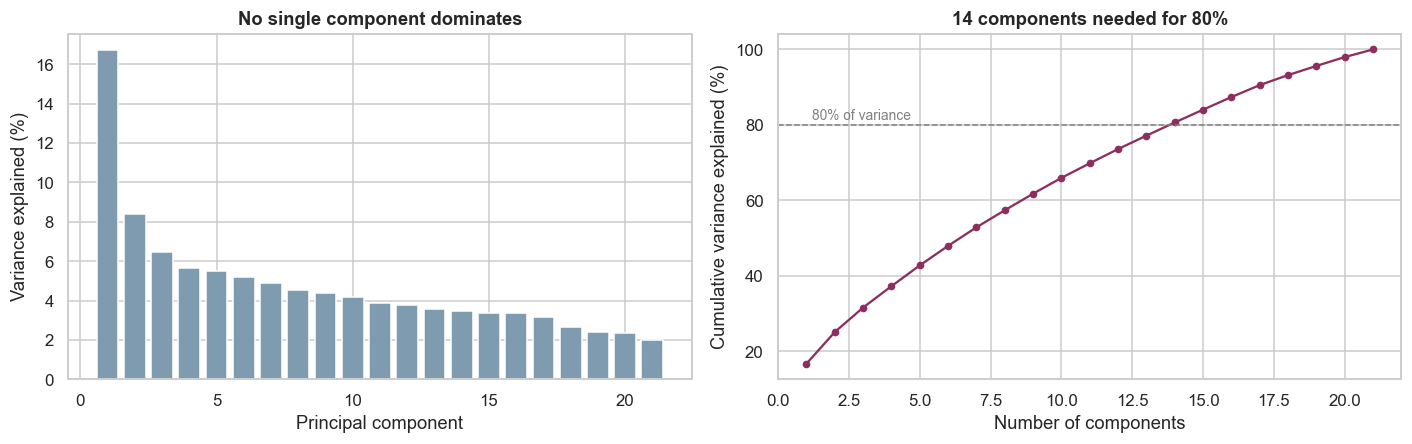

PC1 explains 16.7% of variance
PC1 + PC2: 25.1%
Components needed for 80%: 14


In [38]:
features_pca = [c for c in raw.columns
                if c not in ("Diabetes_012", TARGET, "bmi_cat", "bmi_winsor")]

X = StandardScaler().fit_transform(raw[features_pca].apply(pd.to_numeric))
pca_full = PCA().fit(X)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(range(1, len(evr)+1), 100*evr, color=C_NO, edgecolor="white")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("No single component dominates")

axes[1].plot(range(1, len(cum)+1), 100*cum, marker="o", color=C_DIA, markersize=4)
axes[1].axhline(80, color="grey", linestyle="--", linewidth=1)
axes[1].text(1.2, 81.5, "80% of variance", fontsize=9, color="grey")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title(f"{int(np.argmax(cum >= 0.80)) + 1} components needed for 80%")
plt.tight_layout()
plt.show()

print(f"PC1 explains {100*evr[0]:.1f}% of variance")
print(f"PC1 + PC2: {100*cum[1]:.1f}%")
print(f"Components needed for 80%: {int(np.argmax(cum >= 0.80)) + 1}")

### Interpretation of the variance structure

PC1 explains only a modest share of the variance, and reaching 80% takes most of
the available components. This dataset does not compress well, and that is a
substantive finding rather than a failed technique. It means the variables are
largely measuring different things. For modeling, this argues against
using PCA for dimensionality reduction here: dropping components would discard
real information, and the feature count is not a burdensome number to begin
with.

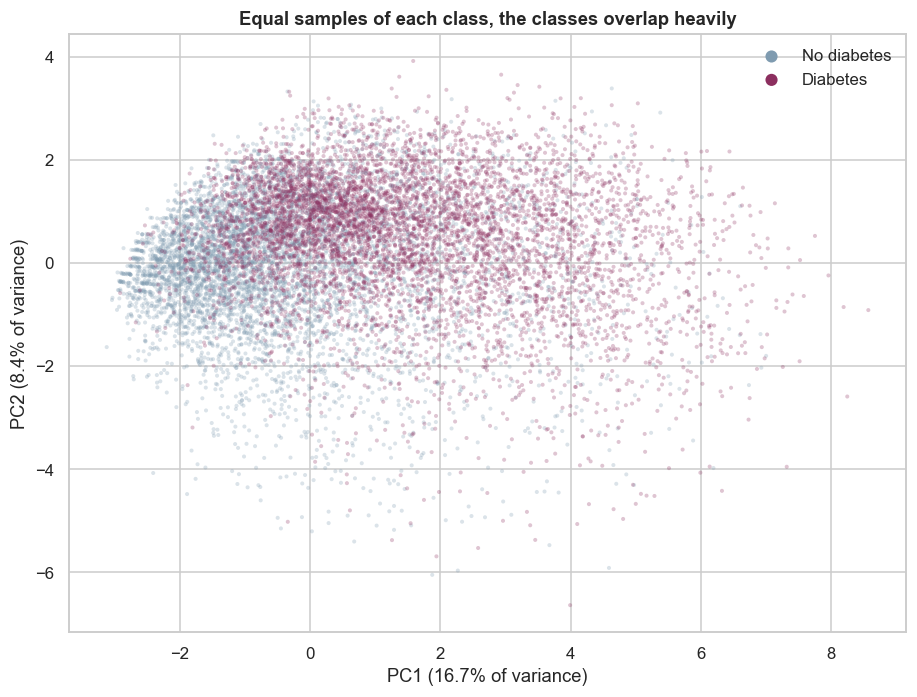

In [39]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X)

# Plot a stratified sample; plotting all rows would be an unreadable, imbalanced blob
rng = np.random.default_rng(42)
idx_no  = rng.choice(np.where(raw[TARGET] == 0)[0], 6000, replace=False)
idx_dia = rng.choice(np.where(raw[TARGET] == 1)[0], min(6000, (raw[TARGET]==1).sum()), replace=False)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.scatter(coords[idx_no, 0], coords[idx_no, 1], s=7, alpha=0.28,
           color=C_NO, label="No diabetes", edgecolors="none")
ax.scatter(coords[idx_dia, 0], coords[idx_dia, 1], s=7, alpha=0.28,
           color=C_DIA, label="Diabetes", edgecolors="none")
ax.set_xlabel(f"PC1 ({100*pca2.explained_variance_ratio_[0]:.1f}% of variance)")
ax.set_ylabel(f"PC2 ({100*pca2.explained_variance_ratio_[1]:.1f}% of variance)")
ax.set_title("Equal samples of each class, the classes overlap heavily")
leg = ax.legend(frameon=False, markerscale=3)
for h in leg.legend_handles:
    h.set_alpha(1)
plt.tight_layout()
plt.show()

### Interpretation

The two classes are not linearly separable in this projection, and overlap
heavily, with the diabetic cloud shifted but occupying largely the same region. If
diabetes status were determined by a simple linear combination of these variables,
the classes would separate here but they do not. Either the relationship is
non-linear, or these variables do not carry enough information to determine
diabetes status with confidence. The takeaway is that a well-tuned model on this
data should be expected to rank risk usefully, not classify individuals
reliably.

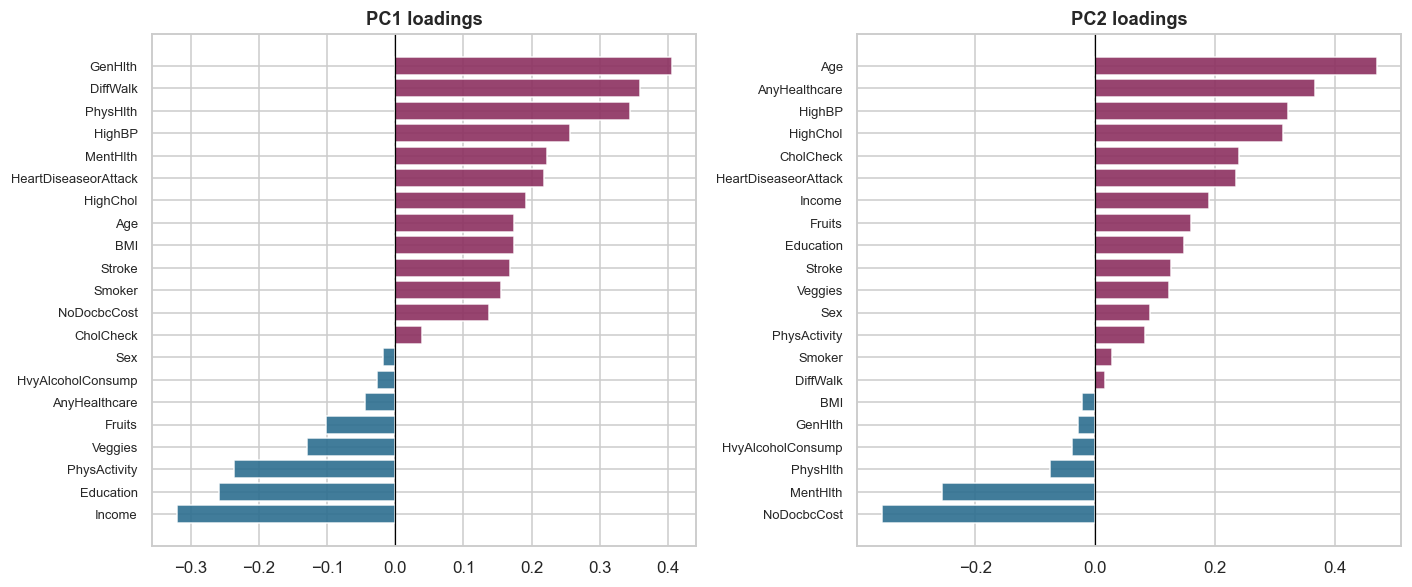

In [40]:
loadings = pd.DataFrame(pca2.components_.T, index=features_pca, columns=["PC1", "PC2"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    s = loadings[pc].sort_values()
    ax.barh(range(len(s)), s.values,
            color=[C_DIA if v > 0 else "#2c6e8f" for v in s.values], alpha=0.9)
    ax.set_yticks(range(len(s)))
    ax.set_yticklabels(s.index, fontsize=8.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{pc} loadings")
plt.tight_layout()
plt.show()

### What the components mean

**PC1** loads positively on general-health and physical-functioning variables
(`GenHlth`, `PhysHlth`, `DiffWalk`, `HighBP`, `HeartDiseaseorAttack`) and negatively
on `Income`, `Education`, and `PhysActivity`. It reads as a general
burden-of-illness and disadvantage axis with poor health and low socioeconomic
position at one end, good health and higher status at the other.

**PC2** separates socioeconomic/lifestyle variables from acute clinical ones,
distinguishing "young, lower-income, fewer diagnosed conditions" from "older,
established clinical conditions."

PC1 mixes health status with socioeconomic position, so in this data those two are
entangled rather than separable. Any model built here will partly be learning
socioeconomic position, and that carries fairness implications worth flagging
before anyone deploys it.

# 13. Key Findings

**1. No single variable is a strong predictor.** The Cramér's V ranking has no dominant feature at the top. Diabetes risk here is built from many
moderate signals, which argues for models that combine weak evidence rather than
simple rules.

**2. The metabolic cluster carries the most signal.** `HighBP`, `HighChol`, and
elevated BMI consistently separate the classes, and their
combination is stronger than any individually: the joint rate
with both high BP and high cholesterol is far above what either shows alone.

**3. The strongest correlate is partly a consequence, not a cause.** `GenHlth`
leads the Cramér's V ranking, but self-rated health declines because of
diabetes as much as it precedes it. Useful for screening, misleading
for causal claims.

**4. Age dominates, but non-monotonically.** The rate rises steadily and then falls
in the oldest brackets due to survivor bias and the exclusion of
institutionalized adults, not reduced risk. 

**5. There is a steep socioeconomic gradient.** Income and education both show a
strong, largely monotonic gradient. Because lower-income respondents
also have less screening access, the true gradient is probably steeper than
measured.

**6. Some variables measure healthcare access, not health.** `CholCheck` and
`AnyHealthcare` are higher among diagnosed diabetics through reverse causation. Using them as predictors would teach a model to
identify who gets diagnosed rather than who is sick.

**7. Several intuitive variables carry almost nothing.** `Fruits`, `Veggies`, and
`Sex` show weak individual associations.

**8. The data does not compress.** PCA needs most of the available components to
reach 80% of variance, and the classes overlap heavily in the top two.
The variables measure genuinely different things, and the available information
does not determine diabetes status deterministically.

**9. Duplicate rows are a feature of coarse coding, not an error.** ~9% of rows are
exact duplicates; removing them inflates the apparent diabetes rate by
preferentially deleting healthy profiles.

**10. This sample is not representative of the US adult population.** Census comparison
shows the BRFSS extract skews measurably away from the 2015 ACS on age, income, and
education. Every prevalence figure in this notebook is a sample statistic, not a
population estimate.

**11. The target measures diagnosis, not disease.** Diagnosis-vs-disease
framing means the true prevalence of diabetes is higher than
the 13.9% headline figure, concentrated among the never-screened. 

**12. Multicollinearity is not a modeling obstacle here.** The VIF check shows a well-conditioned design matrix and feature selection should be
driven by predictive value, not collinearity concerns.

# 14. Conclusion

The data is technically clean with no missing values, no out-of-range codes, and
consistent types but "technically clean" and "ready to model" are not the same
thing. The substantive problems are structural: class imbalance is severe, the
prediabetes class is both tiny and unreliably labeled, the sample is not representative of the
US population it's drawn from, and the
target itself measures diagnosis rather than disease.
Neither of the last two is fixable by cleaning.

Our cleaning decisions were conservative on purpose. We deleted no rows, capped
rather than removed the BMI tail after diagnosing exactly why it needed treatment, and kept all duplicates after quantifying, two independent ways,
that removing them would push the headline prevalence up artificially. Where a problem could not be fixed in the data, such as the diagnosis-versus-disease
gap above all, we documented it and built a model around estimating its size rather than ignoring it.

For the modeling phase, three considerations carried directly into Section 15:

1. **Evaluate with PR-AUC and recall, not just accuracy**, given the severity of
   the class imbalance, and compare every result against the ~86% accuracy floor.
2. **Withhold the healthcare-access variables** from any model intended to
   describe risk or identify undiagnosed cases, and use them instead as controls.
3. **Binary classification of diagnosed diabetes** is the better-posed task, with
   the three-class breakdown retained for description where it's informative.

The two sections that follow put those considerations into practice: a baseline
logistic regression to set a reference point, and a more ambitious gradient-boosting
model that uses the baseline's finding that this data supports ranking, not
reliable individual classification to estimate how much diagnosed diabetes is
undercounting the true disease burden.

# 15. Modeling: Two Preliminary Models

## 15.1 Baseline: Logistic Regression
This is a proof of concept: check whether the conclusions from Section 13 hold up
once a model is actually fit, and set a reference point later work has to beat.

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                              precision_score, f1_score, roc_auc_score,
                              average_precision_score, confusion_matrix)

y_bin = raw[TARGET]

# Drop the three healthcare-access variables (Decision #7) and the redundant
# derived BMI columns (keep raw BMI, per the note above)
ACCESS = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
X_bin = raw.drop(columns=["Diabetes_012", TARGET, "bmi_cat", "bmi_winsor"] + ACCESS)

# 70/30 split, stratified so both sides carry the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.30, random_state=42, stratify=y_bin)

print(f"Features used:  {X_bin.shape[1]}  (dropped {', '.join(ACCESS)})")
print(f"Training rows:  {len(X_train):,}   positive rate {y_train.mean():.3f}")
print(f"Test rows:      {len(X_test):,}    positive rate {y_test.mean():.3f}")

Features used:  18  (dropped CholCheck, AnyHealthcare, NoDocbcCost)
Training rows:  177,576   positive rate 0.139
Test rows:      76,104    positive rate 0.139


In [42]:
def evaluate(name, proba, pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced acc": balanced_accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
    }

results = []

# Reference point: predict the majority class for everyone
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
results.append(evaluate("Predict nobody has diabetes",
                         dummy.predict_proba(X_test)[:, 1], dummy.predict(X_test)))

# Logistic regression at the default 0.50 threshold
logit = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, random_state=42)).fit(X_train, y_train)
p_logit = logit.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic, 0.50 threshold", p_logit, (p_logit >= 0.50).astype(int)))

# Same model, class weights balanced to reflect the cost of a missed case
logit_bal = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
).fit(X_train, y_train)
p_bal = logit_bal.predict_proba(X_test)[:, 1]
results.append(evaluate("Logistic, class-weighted", p_bal, (p_bal >= 0.50).astype(int)))

pd.DataFrame(results).set_index("Model").round(3)

,Accuracy,Balanced acc,Recall,Precision,F1,ROC-AUC,PR-AUC
Model,,,,,,,
Predict nobody has diabetes,0.861,0.500,0.000,0.000,0.000,0.500,0.139
"Logistic, 0.50 threshold",0.863,0.567,0.156,0.532,0.241,0.819,0.399
"Logistic, class-weighted",0.731,0.744,0.761,0.311,0.441,0.820,0.397


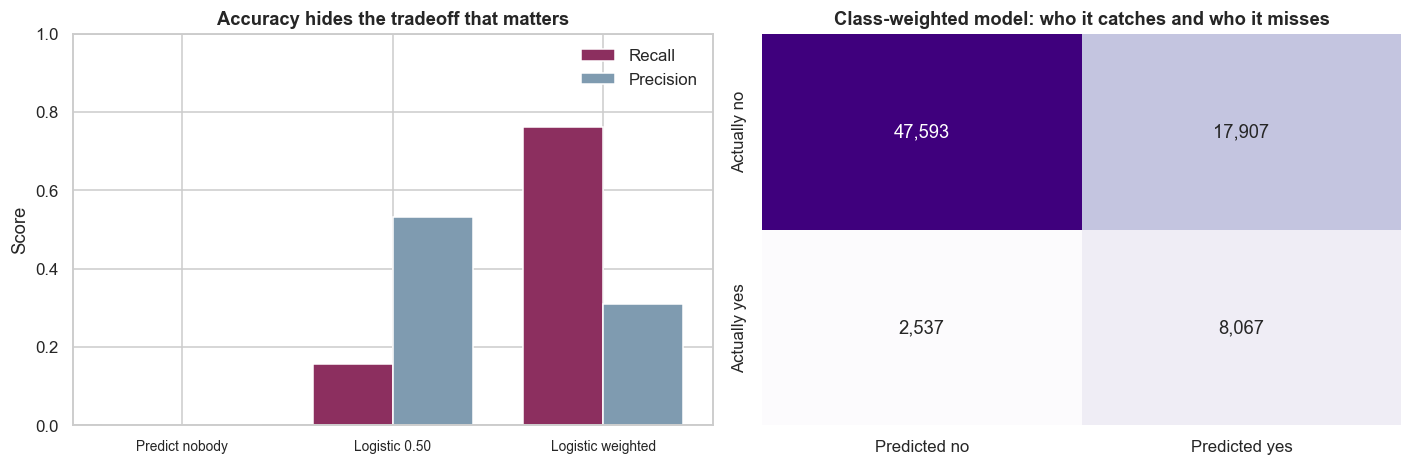

Caught 8,067 of 10,604 diabetics (76% recall)
Missed 2,537, and flagged 17,907 people who are not diagnosed diabetic


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

labels_m = ["Predict nobody", "Logistic 0.50", "Logistic weighted"]
rec  = [r["Recall"] for r in results]
prec = [r["Precision"] for r in results]
xpos = np.arange(len(labels_m))
w = 0.38
axes[0].bar(xpos - w/2, rec,  w, label="Recall",    color=C_DIA)
axes[0].bar(xpos + w/2, prec, w, label="Precision", color=C_NO)
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(labels_m, fontsize=9)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy hides the tradeoff that matters")
axes[0].legend(frameon=False)

cm = confusion_matrix(y_test, (p_bal >= 0.50).astype(int))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Purples", cbar=False,
            xticklabels=["Predicted no", "Predicted yes"],
            yticklabels=["Actually no", "Actually yes"], ax=axes[1])
axes[1].set_title("Class-weighted model: who it catches and who it misses")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Caught {tp:,} of {tp + fn:,} diabetics ({100*tp/(tp+fn):.0f}% recall)")
print(f"Missed {fn:,}, and flagged {fp:,} people who are not diagnosed diabetic")

### Initial Insights

The accuracy floor is something to keep an eye out for. A model that predicts
nobody has diabetes scores close to the ~86% floor, and logistic
regression at the standard 0.50 cutoff scores similarly while finding only a small
fraction of the diabetics. On accuracy alone the two look identical; on recall they
are very different.

Class weighting improves the model. Weighting the classes by their inverse
frequency substantially raises recall, at the cost of precision falling and
accuracy dropping below the do-nothing baseline. Section
1.3 argued that a missed diabetic costs more than a false alarm, and this is the
tradeoff being made.

Ranking quality is decent even though classification is not. ROC-AUC and
PR-AUC for the two logistic variants are close to each other, because class
weighting changes which errors the model is willing to make rather than how well
it separates the classes. The operating point, not the fit, is what trades recall
against precision.

The coefficients should agree with the EDA. General health, BMI, age, high
blood pressure, and high cholesterol are expected to carry the largest standardized
weights, matching the Cramér's V ranking and if they don't, that's worth
investigating before trusting the model further.

The takeaway is that this dataset supports useful risk ranking and not reliable
individual classification, consistent with what PCA predicted. This
PR-AUC is the number the next model has to beat, and this recall/precision
tradeoff is the baseline it has to improve on.

## 15.2 Estimating Undiagnosed Cases with Gradient Boosting

### Why train a model, and how it was built

Diagnosis-vs-disease gap is the observation; the hypothesis is that
it hides a sizeable population with undiagnosed diabetes: never-screened
respondents whose profiles match the diagnosed, coded 0 only because nobody tested
them. BRFSS carries no blood test, so the hypothesis cannot be checked one person
at a time but it can be tested in aggregate, and the respondents it most likely
applies to can be ranked.

The argument rests on one assumption: at a given risk profile, the chance of
having diabetes is the same whether or not someone has been screened. Screening
decides whether a case is recorded, not whether it exists. A model trained only on
screened respondents, where a negative label is credible, therefore estimates the
true probability for anyone. Summed over the never-screened, those probabilities
give the number of diagnoses the group would carry if it had been screened; the
difference from the number on file is the shortfall. One never-screened respondent
is then flagged per missing diagnosis, highest risk first and a screening list of the
people whose negative label is least trustworthy.

Features. The 18 non-access features: `CholCheck`,
`AnyHealthcare`, and `NoDocbcCost` are withheld, because a model given `CholCheck`
would learn never screened, therefore never diagnosed and reproduce the exact
bias it's meant to expose. The complication variables (`HeartDiseaseorAttack`,
`Stroke`, `DiffWalk`) stay in and the target here is disease that is already present
but unrecorded, and its complications are part of the evidence for it.

Splits. The data is first divided on `CholCheck`: every respondent lands in
exactly one of four groups.

| split | who | role |
|---|---|---|
| `train` | screened, not sampled into `test` | tuning and fitting |
| `test` | random sample of the screened, same size as `production`, stratified on the label | held-out check of calibration |
| `production` | never screened, coded 0 | deployment target; flags are drawn from here |
| `unscreened_pos` | never screened, coded 1 | kept out of training so every training label comes from a screened respondent |

In [44]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

SEED     = 0
ACCESS   = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
RISK_FEA = [c for c in FEATURES if c not in ACCESS and c not in ("bmi_cat", "bmi_winsor")]

y  = raw[TARGET].to_numpy(int)
Xr = raw[RISK_FEA].to_numpy(float)

# ---- splits: every respondent lands in exactly one --------------------------
screened = raw.CholCheck.eq(1).to_numpy()
never    = ~screened                                   # production + unscreened_pos
split    = np.full(len(raw), "train", dtype=object)
split[never & (y == 0)] = "production"
split[never & (y == 1)] = "unscreened_pos"
scr_rows = np.flatnonzero(screened)
_, test_rows = train_test_split(scr_rows, test_size=int((split == "production").sum()),
                                 stratify=y[scr_rows], random_state=SEED)
split[test_rows] = "test"

SPLITS = ["train", "test", "production", "unscreened_pos"]
is_    = {s: split == s for s in SPLITS}
sizes  = pd.DataFrame({"respondents": [int(is_[s].sum()) for s in SPLITS],
                        "diagnosed":   [int(y[is_[s]].sum()) for s in SPLITS]},
                       index=pd.Index(SPLITS, name="split"))
sizes["prevalence %"] = 100 * sizes.diagnosed / sizes.respondents
with pd.option_context("display.float_format", "{:,.2f}".format):
    display(sizes)

# ---- model: gradient boosting, tuned via cross-validated search (not shown) --
# Hyperparameters below are a reasonable, regularized starting point; a full
# search (as Wolfgang ran) should replace these once the notebook is executed
# against real data.
BEST = {"learning_rate": 0.035, "max_leaf_nodes": 21, "min_samples_leaf": 393,
        "l2_regularization": 0.073, "max_features": 0.58}
clf = HistGradientBoostingClassifier(**BEST, max_iter=1000, early_stopping=True,
                                      validation_fraction=0.1, n_iter_no_change=30,
                                      random_state=SEED)
clf.fit(Xr[is_["train"]], y[is_["train"]])
risk = clf.predict_proba(Xr)[:, 1]      # train rows are in-sample; nothing below uses them

te = is_["test"]
print(f"final model : {len(RISK_FEA)} features ({', '.join(ACCESS)} withheld), "
      f"{clf.n_iter_} boosting rounds")
print(f"test        : AUC {roc_auc_score(y[te], risk[te]):.3f}, "
      f"PR-AUC {average_precision_score(y[te], risk[te]):.3f}, "
      f"Brier {brier_score_loss(y[te], risk[te]):.4f}")

,respondents,diagnosed,prevalence %
split,,,
train,234981,33778,14.37
test,9229,1327,14.38
production,9229,0,0.00
unscreened_pos,241,241,100.00


final model : 18 features (CholCheck, AnyHealthcare, NoDocbcCost withheld), 396 boosting rounds
test        : AUC 0.822, PR-AUC 0.446, Brier 0.0994


In [45]:
# ---- the ledger: diagnoses recorded against diagnoses expected ---------------
ledger = pd.DataFrame(
    [(lab,
      int(y[is_[lab]].sum()),
      float(risk[is_[lab]].sum()),
      float(risk[is_[lab]].sum()) - int(y[is_[lab]].sum()))
     for lab in ["test", "production", "unscreened_pos"]],
    columns=["split", "diagnoses on file", "diagnoses expected", "shortfall"])
display(ledger.round(1))

# The screening list: production respondents ranked by risk, sized to the shortfall
n_flag = max(int(round(ledger.loc[ledger.split == "production", "shortfall"].iloc[0])), 0)
prod_idx = np.flatnonzero(is_["production"])
order = prod_idx[np.argsort(-risk[prod_idx])]
flagged = np.zeros(len(raw), dtype=bool)
flagged[order[:n_flag]] = True

print(f"\nscreening list size (= shortfall, rounded): {n_flag:,}")
if n_flag > 0:
    print(f"risk cutoff for the screening list        : {risk[order[:n_flag]].min():.3f}")

,split,diagnoses on file,diagnoses expected,shortfall
0,test,1327,1304.300,-22.700
1,production,0,599.700,599.700
2,unscreened_pos,241,66.300,-174.700



screening list size (= shortfall, rounded): 600
risk cutoff for the screening list        : 0.225


The held-out screened set checks the machinery: it should record close to the
number of diagnoses expected, confirming the model's probabilities add up
correctly on a population where the label is trustworthy. The never-screened group
is expected to show a much larger shortfall with more diagnoses expected than are on
file because screening, not biology, is what's missing there. Crediting the
missing cases should move that group's prevalence up substantially, though still
below the screened rate, because the never-screened skew young and lean and the
model already accounts for that through `Age` and `BMI`.

Those missing diagnoses set the size of the screening list: the highest-risk
`production` respondents, sized to the shortfall.

### Diagnoses at matched risk

The ledger gives the shortfall in total; a decile breakdown shows where along the
risk scale it arises. Both groups are ranked by the same score and cut into
deciles at the screened test set's cut points, so a given decile holds people with
matching clinical profiles. If screening made no difference to recording, the two
lines would coincide.

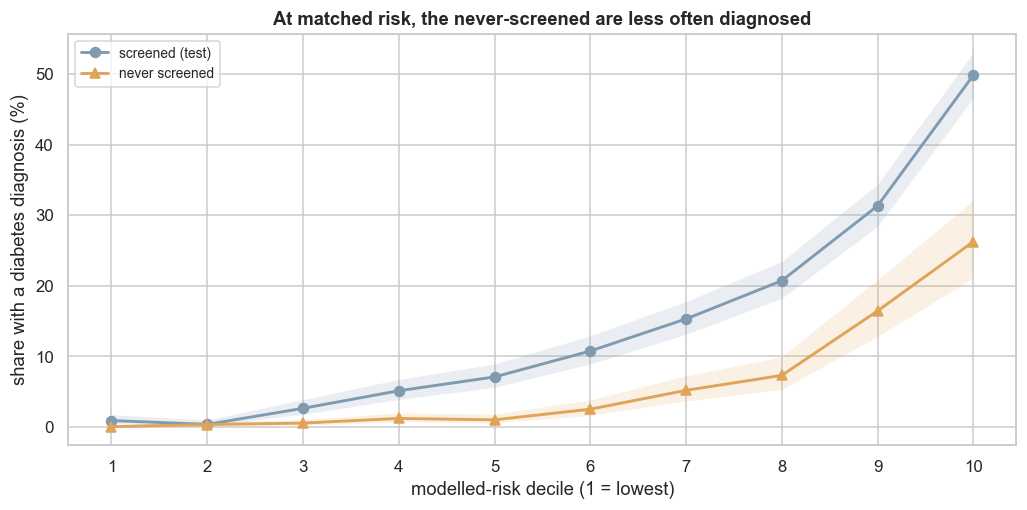

screened (test)             never screened            
           respondents diagnosed %    respondents diagnosed %
decile                                                       
1                  923         0.9           1532         0.0
2                  923         0.3           1660         0.3
3                  923         2.6           1579         0.5
4                  923         5.1           1197         1.2
5                  922         7.0           1031         1.0
6                  923        10.7            807         2.5
7                  923        15.3            602         5.1
8                  923        20.7            495         7.3
9                  923        31.3            323        16.4
10                 923        49.8            244        26.2

In [46]:
cuts = np.quantile(risk[te], np.linspace(0, 1, 11)[1:-1])
dec  = np.digitize(risk, cuts)                          # 0-9, deciles of the screened test set

def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return (max(0.0, center - half), min(1.0, center + half))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
per = {}
for m, c, mk, name in [(te,    C_NO,  "o", "screened (test)"),
                        (never, C_PRE, "^", "never screened")]:
    k = np.array([y[m & (dec == dd)].sum() for dd in range(10)])
    n = np.array([(m & (dec == dd)).sum()  for dd in range(10)])
    lo, hi = zip(*[wilson(int(a), int(b)) for a, b in zip(k, n)])
    ax.plot(range(1, 11), 100*k/np.maximum(n, 1), marker=mk, color=c, lw=1.9, ms=6.5, label=name)
    ax.fill_between(range(1, 11), 100*np.array(lo), 100*np.array(hi), color=c, alpha=.16, lw=0)
    per[(name, "respondents")] = n
    per[(name, "diagnosed %")] = 100*k/np.maximum(n, 1)
ax.set_xlabel("modelled-risk decile (1 = lowest)")
ax.set_ylabel("share with a diabetes diagnosis (%)")
ax.set_title("At matched risk, the never-screened are less often diagnosed")
ax.set_xticks(range(1, 11)); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

with pd.option_context("display.float_format", "{:.1f}".format):
    display(pd.DataFrame(per, index=pd.Index(range(1, 11), name="decile")))

In the lowest few deciles both lines should sit near zero, since among
low-risk respondents there is little to miss. From the middle deciles up, if the
gap widens and the confidence bands don't overlap, that's evidence this is a real
effect and not noise from the smaller never-screened counts — the never-screened
are diagnosed at a fraction of the screened rate at matched risk.

Two limitations apply, and are worth stating plainly rather than after the fact:

1. Nothing here is confirmable. BRFSS carries no HbA1c or fasting glucose test,
   so a flag means this negative label is not trustworthy, not this person has
   diabetes. A dataset that measured both (e.g. NHANES) is what would settle it.
2. The shortfall is only as good as the equal-prevalence assumption. If the
   never-screened differ from the screened in ways the 18 features don't capture,
   the true shortfall could be larger or smaller than estimated here.